# Time Series Forecasting - Team 8

# Pre-process Dataset

In [3]:
import pandas as pd
import numpy as np
import scipy as sp
import sklearn as sk
import polars as pl
import matplotlib.pyplot as plt
import os
import shutil
from IPython.display import display
from google.colab import drive

Optional: run the cell below to obtain the pre-processed train df to skip preprocessing runtime

In [4]:
if not os.path.exists("trained_processed.parquet"):
    !gdown --id 1E8qDLAOQufRefvKdttIY-WmkYnKYY9vw -O trained_processed.parquet

print("Loading data...")
train_df = pl.scan_parquet("trained_processed.parquet")
train_df = train_df.collect()

Loading data...


Or: manually run preprocessing using all the cells below

In [5]:
# Step 1: Download (only if needed)
if not os.path.exists("train.parquet"):
    print("Downloading datasets...")
    !gdown --id 1t1WRvcf2vRKypP_gwOZzUdQNgAsYgcMR -O train.parquet
if not os.path.exists("test.parquet"):
    !gdown --id 1jGh1vmFZMu2uapqF9trm3KZ2A6_elLHx -O test.parquet

# Step 2: Load (fast - local disk)
print("Loading data...")
train_df = pl.scan_parquet("train.parquet")
test_df  = pl.scan_parquet("test.parquet")
print("Data ready. Loading lazily...")

# Print schema
print(test_df.schema)

# Get shape (forces minimal computation)
print("\n\nTrain shape:", train_df.select(pl.len()).collect())
print("\n\nTest shape:", test_df.select(pl.len()).collect())

# Preview data (only loads small sample)
print("\n\nTraining data preview:")
display(train_df.head(5).collect())
print("\n\nTesting data preview:")
display(test_df.head(5).collect())

Loading data...
Data ready. Loading lazily...
Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Int32, 'ts_index': Int32, 'feature_a': Int32, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Float64, 'feature_al'

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,89,29,16.364093,7.464023,5.966933,1.622184,10.26136,4.914369,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",1,89,53,2.858806,5.050617,15.906651,10.879453,3.072151,4.091032,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",3,89,51,9.585452,1.076268,9.004147,16.74049,15.166901,11.427983,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",10,89,44,8.840588,15.034634,4.17078,1.584433,5.383462,3.099428,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,90,28,2.303825,7



Testing data preview:


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",3,3647,95,10.365266,3.209321,8.109339,9.043471,10.123041,15.722121,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",10,3647,88,2.571477,15.234848,16.505699,0.230426,10.145378,10.159641,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",25,3647,71,5.524709,6.931663,8.939537,0.668187,16.578701,3.15069,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",1,3647,97,10.293758,14.89366,9.435544,2.335377,3.477961,15.680595,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…",

In [6]:
train_df = (
    pl.scan_parquet("train.parquet")
    .sort(["id", "code", "sub_code", "sub_category", "ts_index"])
)
# Collect with streaming (key part)
train_df = train_df.collect(streaming=True)

In [7]:
EXCLUDE_COLS = [
    "id",
    "code",
    "sub_code",
    "sub_category",
    "ts_index",
    "y_target",
    "weight"
]

num_cols = [
    col for col in train_df.columns
    if col not in EXCLUDE_COLS
]

# Forward fill
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over(["code", "sub_code", "sub_category"])
    .alias(col)
    for col in num_cols
])

#Median Imputation
global_medians = train_df.select([
    pl.col(col).median().alias(col)
    for col in num_cols
]).to_dict(as_series=False)

global_medians = {k: v[0] for k, v in global_medians.items()}

train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(global_medians[col])
    .alias(col)
    for col in num_cols
])

In [8]:
#Test for nulls
print(train_df.select(
    pl.all().null_count()
))

shape: (1, 94)
┌─────┬──────┬──────────┬──────────────┬───┬────────────┬────────────┬──────────┬────────┐
│ id  ┆ code ┆ sub_code ┆ sub_category ┆ … ┆ feature_cg ┆ feature_ch ┆ y_target ┆ weight │
│ --- ┆ ---  ┆ ---      ┆ ---          ┆   ┆ ---        ┆ ---        ┆ ---      ┆ ---    │
│ u32 ┆ u32  ┆ u32      ┆ u32          ┆   ┆ u32        ┆ u32        ┆ u32      ┆ u32    │
╞═════╪══════╪══════════╪══════════════╪═══╪════════════╪════════════╪══════════╪════════╡
│ 0   ┆ 0    ┆ 0        ┆ 0            ┆ … ┆ 0          ┆ 0          ┆ 0        ┆ 0      │
└─────┴──────┴──────────┴──────────────┴───┴────────────┴────────────┴──────────┴────────┘


Summary Statistics

In [9]:
print(train_df.describe())

shape: (9, 95)
┌────────────┬───────────┬──────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ id        ┆ code     ┆ sub_code ┆ … ┆ feature_c ┆ feature_c ┆ y_target  ┆ weight    │
│ ---        ┆ ---       ┆ ---      ┆ ---      ┆   ┆ g         ┆ h         ┆ ---       ┆ ---       │
│ str        ┆ str       ┆ str      ┆ str      ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64       │
│            ┆           ┆          ┆          ┆   ┆ f64       ┆ f64       ┆           ┆           │
╞════════════╪═══════════╪══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 5337414   ┆ 5337414  ┆ 5337414  ┆ … ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e │
│            ┆           ┆          ┆          ┆   ┆ 6         ┆ 6         ┆ 6         ┆ 6         │
│ null_count ┆ 0         ┆ 0        ┆ 0        ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ mean       ┆ null      ┆ null     ┆ null     ┆ … ┆ 1.061148  ┆ 2.323426  ┆

Feature Distributions

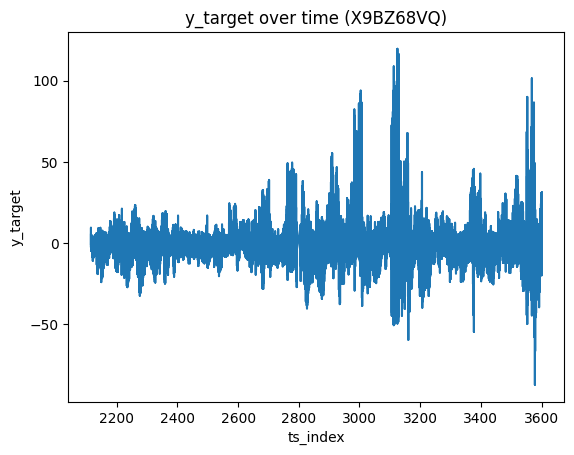

In [10]:
sample_code = train_df.select("code").unique().to_series()[0]

sample_df = (
    train_df
    .filter(pl.col("code") == sample_code)
    .sort("ts_index")
)

plt.figure()
plt.plot(sample_df["ts_index"], sample_df["y_target"])
plt.title(f"y_target over time ({sample_code})")
plt.xlabel("ts_index")
plt.ylabel("y_target")
plt.show()


In [11]:
train_df.sample(10)

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""83EG83KQ__KZSDAYZT__NQ58FVQM__…","""83EG83KQ""","""KZSDAYZT""","""NQ58FVQM""",1.0,2723,32.0,0.1653,10.466532,11.337403,13.95086,3.937226,4.852,0.019757,0.000674,0.003819,0.009548,0.124641,1.027068,-0.004876,0.000724,0.032177,0.048478,0.00144,0.024148,0.193149,0.011412,0.006392,0.07391,-15.155633,-7.894125,0.456705,0.059042,0.074583,0.04837,0.060208,0.001434,…,18.396801,4660.51543,498.769333,9719.167495,74385.177172,64580.300729,770.320718,0.19227,5383.921242,3.406739,81.425755,99.332739,0.612851,1.410601,0.100388,0.116567,1.8696,1.001595,1.609973,-0.291253,-3.178942,-0.150472,0.127531,0.176231,3.962845,-0.00128,-0.000204,-0.000072,-0.000117,-0.006235,-0.001761,0.037671,0.021163,0.081285,1.0,0.000094,2.4921e9
"""OSJL3A7Y__F944N0YE__PHHHVYZI__…","""OSJL3A7Y""","""F944N0YE""","""PHHHVYZI""",10.0,910,4.0,4.160049,7.338575,1.997772,0.62991,4.267335,11.659413,0.037505,0.002765,0.0013,0.006975,0.090403,5.480137,0.0,0.0,0.014782,0.325834,0.01047,0.027652,18.663788,0.603978,20.322364,36.661706,3.424563,54.096831,93.476873,0.0,0.131609,0.057758,0.010209,0.432617,…,0.024886,3480.86774,138.756478,102.531622,9.4376e6,221016.108813,300692.399281,0.000454,249973.151668,26.744415,63857.395645,128405.895109,0.012993,112.384899,155.552869,3.823216,0.628838,0.011606,0.010613,-2.887393,-3.598041,-4.12246,1.411879,0.096705,4.645895,-0.021392,-0.040322,-0.435995,-0.628746,-0.040019,-0.505378,0.02327,3.421619,0.129015,0.0,4.744744,13.36511
"""OSJL3A7Y__KJ1UPD9O__PHHHVYZI__…","""OSJL3A7Y""","""KJ1UPD9O""","""PHHHVYZI""",10.0,3164,71.0,4.1791,5.843375,9.184005,4.582918,3.896617,0.972939,0.02925,0.014121,0.000108,0.002738,0.119579,5.155306,-0.186473,0.010927,0.108424,1.790926,0.051965,0.124436,19.71378,1.26937,19.55864,5.237387,3.424563,24.043036,-67.511075,0.459207,1.089121,0.358172,0.057167,2.380304,…,0.019709,233.116247,22.957474,0.161821,4.4892e6,105132.32061,167371.468659,0.00061,123455.090071,5.653142,7882.468816,74985.829506,0.01029,70.389956,98.704692,2.374247,0.392387,0.006561,0.005161,-2.911147,-3.616939,-3.956574,1.376917,0.096152,4.708907,-0.005753,-0.012307,-0.148247,-0.169508,-0.01222,-0.159875,-4.299312,5.864283,0.466537,3.0,-3.559713,5.579723
"""OSJL3A7Y__69SD4Y3A__NQ58FVQM__…","""OSJL3A7Y""","""69SD4Y3A""","""NQ58FVQM""",25.0,2654,114.0,10.90685,1.212446,16.301705,12.214505,14.257593,5.744586,0.011892,0.002371,0.000228,0.003584,0.074572,4.608971,0.03205,0.001366,0.024513,0.191465,0.010688,0.304177,11.511173,0.291602,8.636958,-5.237387,-1.141521,174.312011,93.476873,0.08269,0.354722,0.055162,0.016938,0.370129,…,0.024749,46.916981,0.973872,6.183681,6.4794e6,232979.391972,316968.445111,0.009714,201105.66766,32.61258,13996.141511,23079.692889,0.012921,234.912172,326.548003,7.865718,0.360241,0.00669,0.00589,-2.863748,-3.588978,-3.925422,1.385467,0.09487,4.654902,-0.003408,-0.006653,-0.072725,-0.105047,-0.006631,-0.081034,0.008146,2.860942,0.108514,6.0,0.83288,1238.631525
"""K7Y1TTAH__5AIUJMDO__N

# Model Evaluation

In [12]:
import numpy as np
import pandas as pd
import gc

from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone

import warnings
warnings.filterwarnings("ignore")

!pip install lightgbm
!pip install xgboost

SEED = 42

Next, we define the dataset with focus on features, weight and target.

In [13]:
ID = "id"
CODE = "code"
SUBCODE = "sub_code"
SUBCATEGORY = "sub_category"
HORIZON = "horizon"
TS_INDEX = "ts_index"
TARGET = "y_target"
WEIGHT = "weight"

N_SPLITS = 5

SAMPLE_FRAC = 0.1
sample_size = int(len(train_df) * SAMPLE_FRAC)

train_df = (
    train_df
    .head(sample_size)
    .sort([CODE, SUBCODE, SUBCATEGORY, TS_INDEX])
)

FEATURES = [c for c in train_df.columns if c not in [ID, CODE, SUBCODE, SUBCATEGORY, HORIZON, TS_INDEX, TARGET, WEIGHT]]

X = train_df.select(FEATURES)
y = train_df.select(TARGET)
w = train_df.select(WEIGHT)

Furthermore, we determine weighted error metric using a flexible weighted RMSE implementation.

In [14]:
def _clip01(x: float) -> float:
    return float(np.minimum(np.maximum(x, 0.0), 1.0))

def weighted_rmse(y_true, y_pred, w) -> float:

    denom = np.sum(w * y_true ** 2)
    # Avoid division by zero
    if denom == 0:
        return 0.0

    ratio = np.sum(w * (y_true - y_pred) ** 2) / denom
    clipped = _clip01(ratio)
    score = 1.0 - clipped
    return np.sqrt(score)

In [15]:
def compute_rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return mean_squared_error(y_true, y_pred, squared=False)

def compute_mae(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return mean_absolute_error(y_true, y_pred)

In [16]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_fold_metrics(y_true, y_pred, splits):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    fold_scores = []

    for fold, (_, val_idx) in enumerate(splits):
        y_val = y_true[val_idx]
        y_pred_val = y_pred[val_idx]

        rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        mae = mean_absolute_error(y_val, y_pred_val)

        fold_scores.append({"fold": fold + 1, "rmse": rmse, "mae": mae})

    mean_rmse = np.mean([f["rmse"] for f in fold_scores])
    mean_mae = np.mean([f["mae"] for f in fold_scores])

    return fold_scores, mean_rmse, mean_mae

Most importantly, we train the baseline model.

In [17]:
def train_model(X, y, w, splits, model):

    X_np = np.asarray(X)
    y_np = np.asarray(y).flatten()
    w_np = np.asarray(w).flatten()

    oof_predictions = np.zeros(len(X_np))

    for fold, (train_idx, val_idx) in enumerate(splits):

        X_train = X_np[train_idx]
        X_val   = X_np[val_idx]

        y_train = y_np[train_idx]
        w_train = w_np[train_idx]

        #scaling
        y_mean = y_train.mean()
        y_std  = y_train.std()
        if y_std < 1e-6:
            y_std = 1.0
        y_train_scaled = (y_train - y_mean) / y_std

        #model
        fold_model = clone(model)
        fold_model.fit(X_train, y_train_scaled, sample_weight=w_train)

        preds_scaled = fold_model.predict(X_val)
        preds = preds_scaled * y_std + y_mean
        preds = np.clip(preds, y_np.min(), y_np.max())

        oof_predictions[val_idx] = preds

    return oof_predictions


hgbr_model = HistGradientBoostingRegressor(
            max_iter=100,
            learning_rate=0.11,
            max_depth=6,
            min_samples_leaf=20,
            l2_regularization=0.5,
            max_bins=255,
            validation_fraction=0.5,
            n_iter_no_change=60,
            random_state=SEED
        )

lightgbm_model = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=0.5,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1
        )

xgboost_model = XGBRegressor(
            n_estimators=1000,
            learning_rate=0.01,
            max_depth=7,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1
        )

In [18]:
tscv = TimeSeriesSplit(n_splits=5, gap=50)
splits = list(tscv.split(X))

oof_preds_hgbr = train_model(X, y, w, splits, hgbr_model)
fold_scores_hgbr, mean_rmse_hgbr, mean_mae_hgbr = compute_fold_metrics(y, oof_preds_hgbr, splits)
weighted_rmse_hgbr = weighted_rmse(
    y.to_numpy().flatten(),
    oof_preds_hgbr,
    w.to_numpy().flatten()
)

oof_preds_lightgbm = train_model(X, y, w, splits, lightgbm_model)
fold_scores_lightgbm, mean_rmse_lightgbm, mean_mae_lightgbm = compute_fold_metrics(y, oof_preds_lightgbm, splits)
weighted_rmse_lightgbm = weighted_rmse(
    y.to_numpy().flatten(),
    oof_preds_lightgbm,
    w.to_numpy().flatten()
)

oof_preds_xgboost = train_model(X, y, w, splits, xgboost_model)
fold_scores_xgboost, mean_rmse_xgboost, mean_mae_xgboost = compute_fold_metrics(y, oof_preds_xgboost, splits)
weighted_rmse_xgboost = weighted_rmse(
    y.to_numpy().flatten(),
    oof_preds_xgboost,
    w.to_numpy().flatten()
)

print("\nHGBR Fold-wise scores:")
for f in fold_scores_hgbr:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")
print(f"Mean RMSE: {mean_rmse_hgbr:.4f}, Mean MAE: {mean_mae_hgbr:.4f}, Weighted: {weighted_rmse_hgbr:.6f}")

print("\nLightBGM Fold-wise scores:")
for f in fold_scores_lightgbm:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")
print(f"Mean RMSE: {mean_rmse_lightgbm:.4f}, Mean MAE: {mean_mae_lightgbm:.4f}, Weighted: {weighted_rmse_lightgbm:.6f}")

print("\nXGBoost Fold-wise scores:")
for f in fold_scores_xgboost:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")
print(f"Mean RMSE: {mean_rmse_xgboost:.4f}, Mean MAE: {mean_mae_xgboost:.4f}, Weighted: {weighted_rmse_xgboost:.6f}")



HGBR Fold-wise scores:
Fold 1 - RMSE: 10.4260, MAE: 5.8104
Fold 2 - RMSE: 0.0822, MAE: 0.0112
Fold 3 - RMSE: 0.0898, MAE: 0.0083
Fold 4 - RMSE: 10.7609, MAE: 2.5263
Fold 5 - RMSE: 14.5908, MAE: 9.2906
Mean RMSE: 7.1899, Mean MAE: 3.5294, Weighted: 0.000000

LightBGM Fold-wise scores:
Fold 1 - RMSE: 10.0944, MAE: 5.6244
Fold 2 - RMSE: 0.0162, MAE: 0.0044
Fold 3 - RMSE: 0.0069, MAE: 0.0040
Fold 4 - RMSE: 10.6710, MAE: 2.4441
Fold 5 - RMSE: 14.1301, MAE: 7.9987
Mean RMSE: 6.9837, Mean MAE: 3.2151, Weighted: 0.000000

XGBoost Fold-wise scores:
Fold 1 - RMSE: 9.9764, MAE: 5.4825
Fold 2 - RMSE: 0.0983, MAE: 0.0277
Fold 3 - RMSE: 0.0504, MAE: 0.0152
Fold 4 - RMSE: 10.6309, MAE: 2.4371
Fold 5 - RMSE: 15.5196, MAE: 10.3576
Mean RMSE: 7.2551, Mean MAE: 3.6640, Weighted: 0.000000


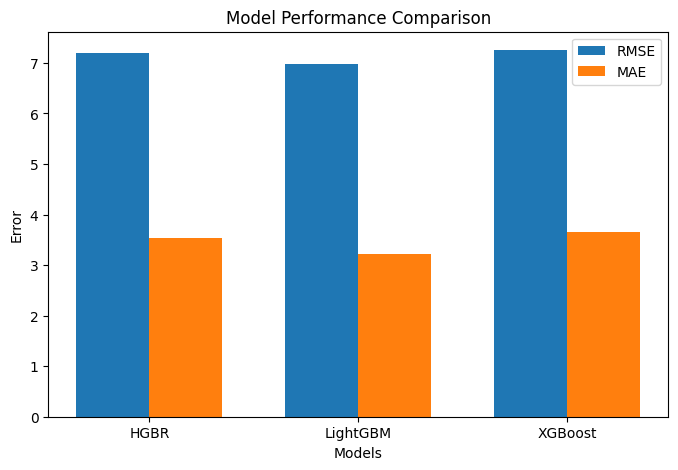

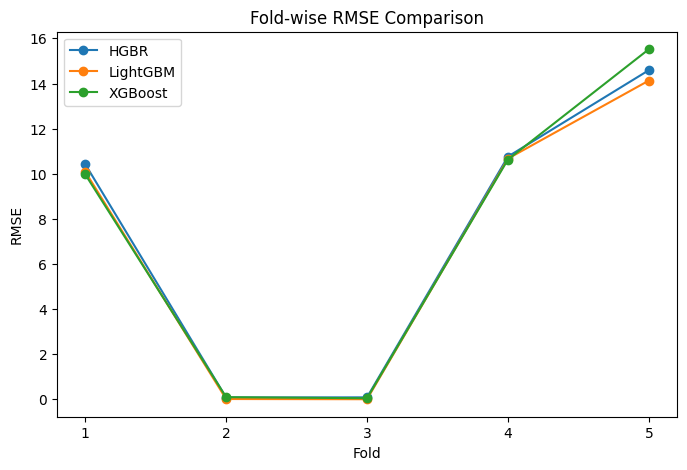

In [19]:
import matplotlib.pyplot as plt
import numpy as np

#Bar Graph
models = ["HGBR", "LightGBM", "XGBoost"]

rmse_scores = [
    mean_rmse_hgbr,
    mean_rmse_lightgbm,
    mean_rmse_xgboost
]

mae_scores = [
    mean_mae_hgbr,
    mean_mae_lightgbm,
    mean_mae_xgboost
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, rmse_scores, width, label="RMSE")
ax.bar(x + width/2, mae_scores, width, label="MAE")

ax.set_title("Model Performance Comparison")
ax.set_xlabel("Models")
ax.set_ylabel("Error")
ax.set_xticks(x)
ax.set_xticklabels(models)

ax.legend()
plt.show()


#Line Graph
folds = [1, 2, 3, 4, 5]

hgbr_rmse = [f["rmse"] for f in fold_scores_hgbr]
lgb_rmse = [f["rmse"] for f in fold_scores_lightgbm]
xgb_rmse = [f["rmse"] for f in fold_scores_xgboost]

plt.figure(figsize=(8, 5))

plt.plot(folds, hgbr_rmse, marker="o", label="HGBR")
plt.plot(folds, lgb_rmse, marker="o", label="LightGBM")
plt.plot(folds, xgb_rmse, marker="o", label="XGBoost")

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("Fold-wise RMSE Comparison")
plt.xticks(folds)

plt.legend()
plt.show()

# Feature Engineering

### Feature Importance

In [18]:
import polars as pl
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

# =====================================
# Validation Splits
# =====================================
def time_splits(n):
    fold_size = n // (N_SPLITS + 1)

    splits = []
    for i in range(1, N_SPLITS + 1):
        train_end = i * fold_size
        val_end = (i + 1) * fold_size

        train_idx = np.arange(0, train_end)
        val_idx = np.arange(train_end, val_end)

        splits.append((train_idx, val_idx))
    return splits

In [19]:
# =====================================
# Computing Temporal Feature Importance
# =====================================
def compute_temporal_importance(df, target, n_repeats=5):
    feature_df = df.select(
        pl.col("^feature.*$"),
        target
    )

    X = feature_df.drop(target)
    y = feature_df.select(target).to_numpy().ravel()

    X_np = X.to_numpy()
    feature_names = X.columns

    splits = time_splits(len(X_np))

    all_importances = []

    for fold, (train_idx, val_idx) in enumerate(splits):
        print(f"Processing fold {fold+1}")

        X_train = X_np[train_idx]
        y_train = y[train_idx]

        X_val = X_np[val_idx]
        y_val = y[val_idx]

        model = HistGradientBoostingRegressor(
            max_iter=100,
            learning_rate=0.1,
            max_depth=6,
            min_samples_leaf=20,
            random_state=SEED
        )

        model.fit(X_train, y_train)

        perm = permutation_importance(
            model,
            X_val,
            y_val,
            n_repeats=n_repeats,
            random_state=SEED,
            n_jobs=-1
        )

        all_importances.append(perm.importances_mean)

    importances_array = np.array(all_importances)

    mean_importance = importances_array.mean(axis=0)
    std_importance = importances_array.std(axis=0)

    stability_score = mean_importance / (std_importance + 1e-6)

    feature_importance_df = pl.DataFrame({
        "feature": feature_names,
        "mean_importance": mean_importance,
        "std_importance": std_importance,
        "stability_score": stability_score
    }).sort("mean_importance", descending=True)

    return feature_importance_df

# =====================================
# Selecting Features (based on stability + importance)
# =====================================
def select_features(
    feature_importance_df,
    unstable_threshold,
    stability_floor=0.5
):
    # Stable
    stable_features = (
        feature_importance_df
        .filter(
            (pl.col("mean_importance") > 0) &
            (pl.col("stability_score") > 1.0)
        )
        .select("feature")
        .to_series()
        .to_list()
    )

    # Unstable but useful
    unstable_features = (
        feature_importance_df
        .filter(
            (pl.col("mean_importance") > unstable_threshold) &
            (pl.col("stability_score") > stability_floor) &
            (pl.col("stability_score") <= 1.0)
        )
        .select("feature")
        .to_series()
        .to_list()
    )

    final_features = list(dict.fromkeys(
        stable_features + unstable_features
    ))

    print(f"Stable: {len(stable_features)}")
    print(f"Unstable added: {len(unstable_features)}")
    print(f"Final total: {len(final_features)}")
    print(f"Final Features: {final_features}")

    return final_features

### Compute Raw Features Importance

In [20]:
# compute importance
importance_df = compute_temporal_importance(train_df, TARGET)

# inspect and select thresholds
print(importance_df.select("mean_importance").describe())

threshold = 0.01

# select features
final_features = select_features(
    importance_df,
    unstable_threshold=threshold
)

Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ mean_importance │
│ ---        ┆ ---             │
│ str        ┆ f64             │
╞════════════╪═════════════════╡
│ count      ┆ 86.0            │
│ null_count ┆ 0.0             │
│ mean       ┆ 63.689305       │
│ std        ┆ 328.340432      │
│ min        ┆ -12.863872      │
│ 25%        ┆ -0.000719       │
│ 50%        ┆ 0.000214        │
│ 75%        ┆ 0.018081        │
│ max        ┆ 2205.7728       │
└────────────┴─────────────────┘
Stable: 1
Unstable added: 17
Final total: 18
Final Features: ['feature_f', 'feature_a', 'feature_ah', 'feature_ai', 'feature_be', 'feature_aj', 'feature_bk', 'feature_y', 'feature_ch', 'feature_h', 'feature_aq', 'feature_al', 'feature_bh', 'feature_v', 'feature_cc', 'feature_bl', 'feature_i', 'feature_af']


In [21]:
#Loads final features from Google Drive instantaneously
import json

if not os.path.exists("final_features.json"):
    print("Downloading final features...")
    !gdown --id 1CVOA5-dRVBvw6BlFGLhc4XuLu0ii83AX -O final_features.json
assert os.path.exists("final_features.json"), "Download failed!"


with open("/content/final_features.json", "r") as f:
    final_features = json.load(f)

print(final_features)

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1CVOA5-dRVBvw6BlFGLhc4XuLu0ii83AX
To: /content/final_features.json
100% 300/300 [00:00<00:00, 1.33MB/s]
['feature_bz', 'feature_bp', 'feature_al', 'feature_bm', 'feature_bo', 'feature_k', 'feature_u', 'feature_bs', 'feature_aj', 'feature_br', 'feature_bc', 'feature_ax', 'feature_ac', 'feature_g', 'feature_h', 'feature_v', 'feature_z', 'feature_a', 'feature_af', 'feature_l', 'feature_am', 'feature_by']


In [22]:
#Obtain the final feature columns
if not os.path.exists("final_features.parquet"):
    print("Downloading dataset...")
    !gdown --id 1mDjBRCZiR-yCA8KnzQPkdBn-lcLWTOUV -O final_features.parquet
assert os.path.exists("final_features.parquet"), "Download failed!"

#Assigned final feature columns to variable. important!
print("Loading data...")
final_df = pl.scan_parquet("final_features.parquet")
print("Processed final feature dataset.")
print(final_df.collect())

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1mDjBRCZiR-yCA8KnzQPkdBn-lcLWTOUV
To: /content/final_features.parquet
100% 48.3M/48.3M [00:00<00:00, 63.9MB/s]
Loading data...
Processed final feature dataset.
shape: (533_741, 22)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ feature_b ┆ feature_b ┆ feature_a ┆ feature_b ┆ … ┆ feature_a ┆ feature_l ┆ feature_a ┆ feature_ │
│ z         ┆ p         ┆ l         ┆ m         ┆   ┆ f         ┆ ---       ┆ m         ┆ by       │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ f64       ┆ ---       ┆ ---      │
│ f64       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆           ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪════

### Compute Horizon Feature Importance

In [23]:
horizon_feature_sets = {}

for h in [1, 3, 10, 25]:
  print(f"\n==== Horizon {h} ====")

  df_h = train_df.filter(pl.col("horizon") == h)

  # compute importance
  importance_df = compute_temporal_importance(df_h, TARGET)

  # inspect and select thresholds
  print(importance_df.select("mean_importance").describe())

  threshold = 0.01

  # select features
  final_features = select_features(
      importance_df,
      unstable_threshold=threshold
  )

  horizon_feature_sets[h] = final_features


==== Horizon 1 ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ mean_importance │
│ ---        ┆ ---             │
│ str        ┆ f64             │
╞════════════╪═════════════════╡
│ count      ┆ 86.0            │
│ null_count ┆ 0.0             │
│ mean       ┆ 106.199966      │
│ std        ┆ 513.22213       │
│ min        ┆ -129.098765     │
│ 25%        ┆ -0.008921       │
│ 50%        ┆ 0.00134         │
│ 75%        ┆ 3.157129        │
│ max        ┆ 4131.262811     │
└────────────┴─────────────────┘
Stable: 0
Unstable added: 25
Final total: 25
Final Features: ['feature_ai', 'feature_av', 'feature_y', 'feature_bk', 'feature_ce', 'feature_c', 'feature_b', 'feature_e', 'feature_bj', 'feature_w', 'feature_aj', 'feature_al', 'feature_d', 'feature_g', 'feature_ad', 'feature_at', 'feature_au', 'feature_bi', 'feature_z', 'feature_ab', 'feature_ca', 'feature_be', 'feature_i', 'feat

KeyboardInterrupt: 

In [ ]:
#Outputs and downloads horizon feature sets instantaneously from drive
import json

if not os.path.exists("horizon_feature_sets.json"):
    print("Downloading horizon features...")
    !gdown --id 1CVOA5-dRVBvw6BlFGLhc4XuLu0ii83AX -O horizon_feature_sets.json
assert os.path.exists("horizon_feature_sets.json"), "Download failed!"

with open("/content/horizon_feature_sets.json", "r") as f:
    horizon_feature_sets = json.load(f)

print(horizon_feature_sets)

### Compute Lag Feature Importance

In [ ]:
#Lag Features Instant Output
import os
import polars as pl

if not os.path.exists("lag_features.parquet"):
        print("Downloading results...")
        !gdown --id 1GgqMlFgNpuIas2RbzoyUR9dGPrnPvH-3 -O lag_features.parquet

print("Loading data...")
lag_results = pl.scan_parquet("lag_features.parquet").collect()
print(lag_results)


In [ ]:
# Generate lag features
def generate_lags(df, feature_cols, lag, group_col=CODE):
    lag_exprs = []
    for col in feature_cols:
          lag_exprs.append (
              pl.col(col)
              .shift(lag)
              .over(group_col)
              .alias(f"feature_lag_{lag}_{col}")
          )
    return df.with_columns(lag_exprs)


# Lags to evaluate
lags = [1, 3, 5, 10, 25]

results = []
selected_lag_features = []

for lag in lags:
    print(f"\n==== Testing lag: {lag} ====")

    # Generate lag features
    df_lagged = generate_lags(train_df.clone(), FEATURES, lag, [CODE, SUBCODE, SUBCATEGORY])

    # Compute temporal importance
    importance_df = compute_temporal_importance(df_lagged, TARGET)

    # Extract lag feature stats
    lag_features = [f"feature_lag_{lag}_{col}" for col in FEATURES]

    lag_importance = (
          importance_df
          .filter(pl.col("feature").is_in(lag_features))
          .with_columns(
              (
                  pl.col("mean_importance") *
                  pl.col("stability_score").clip(lower_bound=0).sqrt()
              ).alias("score")
          )
          .sort("score", descending=True)
      )

    selected_features_df = lag_importance.filter(
          (pl.col("mean_importance") > 0.005) &
          (pl.col("stability_score") > 1.0)
    )

    filtered_lag_features = (
          selected_features_df
          .get_column("feature")
          .to_list()
    )

    selected_lag_features.extend(filtered_lag_features)
    selected_lag_features = sorted(set(selected_lag_features))

    # Stats
    num_signal = lag_importance.filter(pl.col("mean_importance") > 0).height
    avg_importance = lag_importance["mean_importance"].mean()
    avg_stability = lag_importance["stability_score"].mean()
    avg_score = lag_importance["score"].mean()

    print(f"Lag features with signal: {num_signal}")
    print(f"Avg importance: {avg_importance}")
    print(f"Avg stability: {avg_stability}")
    print(f"Avg score: {avg_score}")

    print("\nTop lag features:")
    print(lag_importance.head(10))

    print(f"\nSelected features for lag {lag}:")
    print(filtered_lag_features)

    # Store results
    results.append({
        "lag": lag,
        "avg_lag_importance": avg_importance,
        "avg_lag_stability": avg_stability,
        "avg_score": avg_score,
        "top_lag_features": lag_importance.head(5),
        "selected_features": filtered_lag_features
    })

print("\n==== FINAL SELECTED LAG FEATURES ====")
print(selected_lag_features)
print(f"Total selected lag features: {len(selected_lag_features)}")

### Rolling Window Features

In [ ]:
#Rolling Window Feature Instant Output(MEAN)
import os
import polars as pl

if not os.path.exists("rolling_mean_features.parquet"):
        print("Downloading results...")
        !gdown --id 1ojdCQgLjr5tYsbM64SzzCk2HZGp8idO5 -O rolling_mean_features.parquet

print("Loading data...")
rolling_mean_results = pl.scan_parquet("rolling_mean_features.parquet").collect()
print(rolling_mean_results)

#Rolling Window Feature Instant Output(STD)
import os
import polars as pl

if not os.path.exists("rolling_std_features.parquet"):
        print("Downloading results...")
        !gdown --id 1vbT9RHLLTLfMV92FrCQBKOcqTyHbF64O -O rolling_std_features.parquet

print("Loading data...")
rolling_std_features_results = pl.scan_parquet("rolling_std_features.parquet").collect()
print(rolling_std_features_results)

In [ ]:
def generate_rolling(df, feature_cols, window, group_col=CODE, stat="mean"):
    rolling_exprs = []

    for col in feature_cols:
        shifted = pl.col(col).shift(1)

        if "mean" == stat:
                rolling_exprs.append(
                    shifted.rolling_mean(window).over(group_col)
                    .alias(f"feature_rolling_mean_{window}_{col}")
                )

        elif "std" == stat:
                rolling_exprs.append(
                    shifted.rolling_std(window).over(group_col)
                    .alias(f"feature_rolling_std_{window}_{col}")
                )

        elif "skew" == stat:
                rolling_exprs.append(
                    shifted.rolling_skew(window).over(group_col)
                    .alias(f"feature_rolling_skew_{window}_{col}")
                )

        elif "kurt" == stat:
                rolling_exprs.append(
                    shifted.rolling_kurtosis(window).over(group_col)
                    .alias(f"feature_rolling_kurt_{window}_{col}")
                )

        else:
            raise ValueError(f"Unknown stat: {stat}")

    return df.with_columns(rolling_exprs)


# Rolling Windows
windows = [3, 5, 10, 25]

def test_rolling_window(stat):
  results = []
  all_selected_features = []

  for window in windows:
      print(f"\n==== Testing window: {window} ====")

      df_roll = generate_rolling(train_df.clone(), FEATURES, window, [CODE, SUBCODE, SUBCATEGORY], stat)

      importance_df = compute_temporal_importance(df_roll, TARGET)

      roll_features = [
          f"feature_rolling_{stat}_{window}_{col}"
          for col in FEATURES
      ]

      roll_importance = (
          importance_df
          .filter(pl.col("feature").is_in(roll_features))
          .with_columns(
              (
                  pl.col("mean_importance") *
                  pl.col("stability_score").clip(lower_bound=0).sqrt()
              ).alias("score")
          )
          .sort("score", descending=True)
      )

      selected_features_df = roll_importance.filter(
          (pl.col("mean_importance") > 0.005) &
          (pl.col("stability_score") > 1.0)
      )

      selected_rolling_features = (
          selected_features_df
          .get_column("feature")
          .to_list()
      )

      all_selected_features.extend(selected_rolling_features)
      all_selected_features = list(set(all_selected_features))

      # Stats
      num_signal = roll_importance.filter(pl.col("mean_importance") > 0).height
      avg_importance = roll_importance["mean_importance"].mean()
      avg_stability = roll_importance["stability_score"].mean()
      avg_score = roll_importance["score"].mean()

      print(f"Rolling features with signal: {num_signal}")
      print(f"Avg importance: {avg_importance}")
      print(f"Avg stability: {avg_stability}")
      print(f"Avg score: {avg_score}")

      print("\nTop rolling features:")
      print(roll_importance.head(10))

      results.append({
          "window": window,
          "num_signal": num_signal,
          "avg_importance": avg_importance,
          "avg_stability": avg_stability,
          "avg_score": avg_score,
          "top_features": roll_importance.head(5),
          "selected_features": selected_rolling_features
      })

  return results, all_selected_features

Rolling Window Mean

In [ ]:
results, selected_rolling_features = test_rolling_window("mean")

Rolling Window STD

In [ ]:
results, selected_rolling_features = test_rolling_window("std")

### Horizon Based Features

In [ ]:
import os
import polars as pl

if not os.path.exists("horizon_based_features_j.parquet"):
        print("Downloading results...")
        !gdown --id 11z6ZhNHfimxj8W2rwhmTgiH3rLx0tilv -O horizon_based_features_j.parquet

print("Loading data...")
h_results = pl.scan_parquet("horizon_based_features_j.parquet").collect()
print(h_results)

In [ ]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.base import clone

# =========================================================
# CONFIG
# =========================================================

def get_important_base_features(
    X_base,
    y_base,
    target,
    excluded_cols=None,
    importance_threshold=0.01,
    stability_floor=0.5,
    top_k=None
):

    # -----------------------------------------
    # Default exclusions
    # -----------------------------------------

    if excluded_cols is None:
        excluded_cols = set()

    # -----------------------------------------
    # Importance computation
    # -----------------------------------------

    importance_input = X_base.hstack(y_base)

    base_importance = compute_temporal_importance(
        importance_input,
        target
    )

    # -----------------------------------------
    # Remove metadata columns
    # -----------------------------------------

    base_importance = (
        base_importance
        .filter(
            ~pl.col("feature").is_in(excluded_cols)
        )
    )

    # -----------------------------------------
    # Stability-adjusted scoring
    # -----------------------------------------

    base_importance = (
        base_importance
        .with_columns(
            (
                pl.col("mean_importance") *
                pl.col("stability_score")
                .clip(lower_bound=0)
                .sqrt()
            ).alias("score")
        )
        .sort("score", descending=True)
    )

    # -----------------------------------------
    # Threshold filtering
    # -----------------------------------------

    filtered = (
        base_importance
        .filter(
            (pl.col("mean_importance") > importance_threshold) &
            (pl.col("stability_score") >= stability_floor)
        )
    )

    # -----------------------------------------
    # Optional top-k truncation
    # -----------------------------------------

    if top_k is not None:
        filtered = filtered.head(top_k)

    selected_features = filtered["feature"].to_list()

    return (
        selected_features,
        filtered
    )

# =========================================================
# BASE DATA
# =========================================================

X_base = (
    X.clone()
    .with_columns(
        train_df["horizon"]
            .alias("horizon")
    )
)

EXCLUDED_COLS = {
    TARGET,
    "horizon",
    "code",
    "sub_code",
    "ts_index"
}

y_base = train_df.select(TARGET)

important_cols, base_importance = (
    get_important_base_features(
        X_base,
        y_base,
        TARGET,
        excluded_cols=EXCLUDED_COLS,
        importance_threshold=0.01,
        stability_floor=0.7,
        top_k=8
    )
)

horizon_sensitive_cols = (
    base_importance
    .filter(
        pl.col("stability_score") < 0.8
    )
    ["feature"]
    .to_list()
)

important_cols=horizon_sensitive_cols

# =========================================================
# HORIZON FEATURE ENGINEERING
# =========================================================

def create_horizon_features(
    X,
    important_cols,
    horizons=(1, 3, 10, 25)
):
    X_new = X.clone()

    interaction_features = []
    exprs = []

    # -------------------------------------------------
    # Horizon dummy + interaction features
    # -------------------------------------------------

    for horizon in horizons:

        # -----------------------------
        # Horizon dummy feature
        # -----------------------------

        dummy_col = f"is_h{horizon}"

        exprs.append(
            (
                pl.col("horizon") == horizon
            )
            .cast(pl.Float32)
            .alias(dummy_col)
        )

        interaction_features.append(dummy_col)

        # -----------------------------
        # Horizon interaction features
        # -----------------------------

        horizon_mask = (
            pl.col("horizon") == horizon
        ).cast(pl.Float32)

        for col in important_cols:

            if col == "horizon":
              continue

            if col not in X_new.columns:
                continue

            new_col = f"{col}_x_h{horizon}"

            exprs.append(
                (
                    pl.col(col).cast(pl.Float32) * horizon_mask
                ).alias(new_col)
            )

            interaction_features.append(new_col)

    # -------------------------------------------------
    # Apply all expressions once
    # -------------------------------------------------

    X_new = X_new.with_columns(exprs)

    return X_new, interaction_features

# =========================================================
# HORIZON FEATURE PIPELINE
# =========================================================

def build_horizon_pipeline(
    X_base,
    y_base,
    target,
    important_cols,
    unstable_threshold=0.002
):

    # -----------------------------------------
    # Feature generation
    # -----------------------------------------

    X_horizon, created_features = (
    create_horizon_features(
        X_base,
        important_cols,
        horizons=(1, 3, 10, 25)
    )
)

    print(f"Original shape: {X_base.shape}")
    print(f"New shape: {X_horizon.shape}")

    # -----------------------------------------
    # Importance evaluation
    # -----------------------------------------

    importance_input = X_horizon.hstack(y_base)

    importance_df = compute_temporal_importance(
        importance_input,
        target
    )

    # -----------------------------------------
    # Horizon-only filtering
    # -----------------------------------------

    horizon_feature_set = created_features

    horizon_importance = (
        importance_df
        .filter(
            pl.col("feature")
            .is_in(horizon_feature_set)
        )
        .with_columns(
            (
                pl.col("mean_importance") *
                pl.col("stability_score")
                .clip(lower_bound=0)
                .sqrt()
            ).alias("score")
        )
        .sort("score", descending=True)
    )

    # -----------------------------------------
    # Feature selection
    # -----------------------------------------

    selected_features = select_features(
        horizon_importance,
        unstable_threshold=unstable_threshold,
        stability_floor=0.5
    )

    # -----------------------------------------
    # Diagnostics
    # -----------------------------------------

    diagnostics = {
        "num_signal": (
            horizon_importance
            .filter(pl.col("mean_importance") > 0)
            .height
        ),
        "avg_importance": (
            horizon_importance["mean_importance"]
            .mean()
        ),
        "avg_stability": (
            horizon_importance["stability_score"]
            .mean()
        ),
        "avg_score": (
            horizon_importance["score"]
            .mean()
        )
    }

    print("\n===================================")
    print("HORIZON FEATURE SUMMARY")
    print("===================================")

    for k, v in diagnostics.items():
        print(f"{k}: {v}")

    print("\nTop Horizon Features:")
    print(horizon_importance.head(10))

    print("\nSelected Features:")
    print(selected_features)

    return (
        X_horizon,
        horizon_importance,
        selected_features
    )

# =========================================================
# RUN PIPELINE
# =========================================================

(
    X_horizon,
    horizon_importance,
    selected_horizon_features
) = build_horizon_pipeline(
    X_base=X_base,
    y_base=y_base,
    target=TARGET,
    important_cols=important_cols
)

# =========================================================
# FINAL FEATURE MATRIX
# =========================================================

final_features = list(dict.fromkeys(
    important_cols +
    selected_horizon_features +
    ["horizon"]
))

X_final = X_horizon.select(final_features)

## Trend/Difference Feature

In [ ]:
import os
import polars as pl

if not os.path.exists("diff_features.parquet"):
        print("Downloading results...")
        !gdown --id 1unudPl7lqVkFxg5jX-PLkvV7SfIfNIat -O diff_features.parquet

print("Loading data...")
diff_results = pl.scan_parquet("diff_features.parquet").collect()
print(diff_results)

In [ ]:
#Create Difference Features
def generate_diff_features(df, feature_cols, group_col=CODE):
    diff_exprs = []

    for col in feature_cols:
        shifted = pl.col(col).over(group_col)
        diff_exprs.append(
            (shifted - shifted.shift(1))
            .alias(f"feature_diff_{col}")
        )

    return df.with_columns(diff_exprs)

#Apply to Dataset
results = []

print("\n==== Testing Difference Features ====")

# Generate difference features
df_diff = generate_diff_features(
    train_df.clone(),
    FEATURES,
    [CODE, SUBCODE, SUBCATEGORY]
)

# Compute importance
importance_df = compute_temporal_importance(df_diff, TARGET)

# Extract difference features
diff_features = [f"feature_diff_{col}" for col in FEATURES]

diff_importance = (
    importance_df
    .filter(pl.col("feature").is_in(diff_features))
    .with_columns(
        (
            pl.col("mean_importance") *
            pl.col("stability_score")
                .clip(lower_bound=0)
                .log1p()
        ).alias("score")
    )
    .sort("score", descending=True)
)

selected_features_df = diff_importance.filter(
    (pl.col("mean_importance") > 0.001) &
    (pl.col("stability_score") > 0.5)
)

selected_diff_features = (
    selected_features_df
    .sort("score", descending=True)
    .get_column("feature")
    .to_list()
)

# Stats
num_signal = diff_importance.filter(pl.col("mean_importance") > 0).height
avg_importance = diff_importance["mean_importance"].mean()
avg_stability = diff_importance["stability_score"].mean()
avg_score = diff_importance["score"].mean()

print(f"Difference features with signal: {num_signal}")
print(f"Avg importance: {avg_importance}")
print(f"Avg stability: {avg_stability}")
print(f"Avg score: {avg_score}")

print("\nTop difference features (by score):")
print(diff_importance.head(10))

# Store results
results.append({
    "feature_type": "difference",
    "num_signal": num_signal,
    "avg_importance": avg_importance,
    "avg_stability": avg_stability,
    "avg_score": avg_score,
    "top_features": diff_importance.head(5),
    "selected_features": selected_diff_features
})

In [ ]:
labels = ["Baseline", "With Diff"]

rmse_vals = [mean_rmse, mean_rmse_diff]
mae_vals = [mean_mae, mean_mae_diff]

x = np.arange(len(labels))

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, rmse_vals, width=0.4, label="RMSE")
plt.bar(x + 0.2, mae_vals, width=0.4, label="MAE")

plt.xticks(x, labels)
plt.title("Performance Comparison")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

### Evaluation of Trend/Difference feature
The introduction of lag-1 difference features (x_t - x_{t-1}) was intended to capture short-term temporal changes within each code group, allowing the model to detect sudden deviations or behavioral shifts that may not be visible in the raw feature values alone. However, the experimental results show that including these features did not produce any measurable improvement in performance. Both RMSE and MAE remained essentially unchanged compared to the baseline model, indicating that the additional features did not contribute meaningful predictive signal.

This suggests that the original feature set already contains sufficient information for the model, or that the model itself is capable of implicitly learning temporal relationships without explicitly engineered difference features. It is also possible that the dataset does not exhibit strong short-term variation, or that differencing introduced noise that offset any potential benefit. As a result, the lag-1 difference features do not justify inclusion in the final model, reinforcing the importance of empirically validating feature engineering choices rather than assuming their effectiveness.

## Group-Based Feature




In [ ]:
import numpy as np
import pandas as pd
import polars as pl
import gc
import warnings

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")

SEED       = 42
ID         = "id"
CODE       = "code"
SUBCODE    = "sub_code"
SUBCATEGORY= "sub_category"
HORIZON    = "horizon"
TS_INDEX   = "ts_index"
TARGET     = "y_target"
WEIGHT     = "weight"
VOLATILITY = "y_volatility"
ROLLING_MEAN = "y_rolling_mean"
SAMPLE_FRAC  = 0.1
N_SPLITS     = 5

EXCLUDE_COLS = [ID, CODE, SUBCODE, SUBCATEGORY, HORIZON, TS_INDEX,
                TARGET, WEIGHT, VOLATILITY, ROLLING_MEAN]

print("=" * 65)
print("  Cell 17 — Group-Based Feature Engineering & Evaluation")
print("=" * 65)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — Reload the processed training data (same slice as baseline)
# ─────────────────────────────────────────────────────────────────────────────
print("\n[1/4] Loading processed training data …")

train_raw = (
    pl.scan_parquet("train_processed.parquet")
    .collect()
    .sample(fraction=SAMPLE_FRAC, seed=SEED)
    .sort(TS_INDEX)
)

print(f"    Loaded {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns")



In [ ]:
# Group-Based Aggregations

print("\n[2/4] Engineering group-based aggregation features …")

GROUP_LEVELS = [CODE, SUBCODE, SUBCATEGORY]

AGG_EXPRS = []
for grp in GROUP_LEVELS:
    safe = grp.replace("/", "_")
    AGG_EXPRS += [
        pl.col(TARGET).mean().over(grp).alias(f"grp_mean_{safe}"),
        pl.col(TARGET).std().over(grp).alias(f"grp_std_{safe}"),
        pl.col(TARGET).median().over(grp).alias(f"grp_median_{safe}"),
        # ratio of current value to group mean (relative position)
        (pl.col(TARGET) / (pl.col(TARGET).mean().over(grp) + 1e-8))
            .alias(f"grp_ratio_{safe}"),
        # rolling mean within group (window = 5)
        pl.col(TARGET)
            .rolling_mean(window_size=5)
            .over(grp)
            .alias(f"grp_roll5_{safe}"),
        # rolling std within group (window = 5) — local volatility proxy
        pl.col(TARGET)
            .rolling_std(window_size=5)
            .over(grp)
            .alias(f"grp_rollstd5_{safe}"),
    ]

train_eng = train_raw.with_columns(AGG_EXPRS)

# ── Within-group Z-score normalisation (STEP 2b) ────────────────────────────
print("    Normalising features within groups …")

NORM_TARGETS = [f"grp_mean_{g.replace('/','_')}" for g in GROUP_LEVELS] + \
               [f"grp_roll5_{g.replace('/','_')}" for g in GROUP_LEVELS]

NORM_EXPRS = []
for col in NORM_TARGETS:
    for grp in GROUP_LEVELS:
        safe_grp = grp.replace("/", "_")
        new_name = f"{col}_znorm_{safe_grp}"
        NORM_EXPRS.append(
            ((pl.col(col) - pl.col(col).mean().over(grp)) /
             (pl.col(col).std().over(grp) + 1e-8))
            .alias(new_name)
        )

train_eng = train_eng.with_columns(NORM_EXPRS)

# ── Identify the new feature columns ────────────────────────────────────────
BASE_FEATURES = [c for c in train_raw.columns  if c not in EXCLUDE_COLS]
NEW_FEATURES  = [c for c in train_eng.columns
                 if c not in train_raw.columns and c not in EXCLUDE_COLS]
ALL_FEATURES  = BASE_FEATURES + NEW_FEATURES

print(f"    Base features : {len(BASE_FEATURES)}")
print(f"    New features  : {len(NEW_FEATURES)}")
print(f"    Total features: {len(ALL_FEATURES)}")
print(f"\n    New feature names (first 12):")
for f in NEW_FEATURES[:12]:
    print(f"        {f}")
if len(NEW_FEATURES) > 12:
    print(f"        … and {len(NEW_FEATURES)-12} more")



In [ ]:

# Retrain Model with Enriched Feature Set
print("\n[3/4] Retraining model with group-based features …")

X_eng = train_eng.select(ALL_FEATURES).to_numpy()
y_np  = train_eng.select(TARGET).to_numpy().flatten()
w_np  = np.ones(len(X_eng))          # uniform weights (same as baseline)

tscv   = TimeSeriesSplit(n_splits=N_SPLITS)
splits = list(tscv.split(X_eng))

# ── Weighted RMSE (competition metric) ──────────────────────────────────────
def _clip01(x):
    return float(np.clip(x, 0.0, 1.0))

def weighted_rmse(y_true, y_pred, w):
    denom  = np.sum(w * y_true ** 2)
    ratio  = np.sum(w * (y_true - y_pred) ** 2) / (denom + 1e-12)
    return float(np.sqrt(_clip01(ratio)))

# ── Fold-level metrics ───────────────────────────────────────────────────────
def compute_fold_metrics(y_true, y_pred, splits):
    fold_scores = []
    for fold, (_, val_idx) in enumerate(splits):
        y_v, p_v = y_true[val_idx], y_pred[val_idx]
        rmse = np.sqrt(mean_squared_error(y_v, p_v))
        mae  = mean_absolute_error(y_v, p_v)
        fold_scores.append({"fold": fold + 1, "rmse": rmse, "mae": mae})
    mean_rmse = np.mean([f["rmse"] for f in fold_scores])
    mean_mae  = np.mean([f["mae"]  for f in fold_scores])
    return fold_scores, mean_rmse, mean_mae

# ── Training loop ────────────────────────────────────────────────────────────
oof_preds_eng = np.zeros(len(X_eng))

for fold, (train_idx, val_idx) in enumerate(splits):
    X_tr, X_vl = X_eng[train_idx], X_eng[val_idx]
    y_tr        = y_np[train_idx]
    w_tr        = w_np[train_idx]

    y_mean = y_tr.mean();  y_std = max(y_tr.std(), 1e-6)
    y_tr_sc = (y_tr - y_mean) / y_std

    model = HistGradientBoostingRegressor(
        max_iter          = 100,
        learning_rate     = 0.11,
        max_depth         = 6,
        min_samples_leaf  = 20,
        l2_regularization = 0.5,
        max_bins          = 255,
        validation_fraction = 0.5,
        n_iter_no_change  = 60,
        random_state      = SEED,
    )
    model.fit(X_tr, y_tr_sc, sample_weight=w_tr)

    preds = model.predict(X_vl) * y_std + y_mean
    preds = np.clip(preds, y_np.min(), y_np.max())
    oof_preds_eng[val_idx] = preds

    print(f"    Fold {fold+1}/{N_SPLITS} complete")

gc.collect()



In [ ]:

# Compare & Document Performance vs Baseline
print("\n[4/4] Comparing performance vs baseline …")

# ── Baseline scores (re-computed on the same sample for fair comparison) ────
X_base = train_raw.select(BASE_FEATURES).to_numpy()
oof_preds_base = np.zeros(len(X_base))

for fold, (train_idx, val_idx) in enumerate(splits):
    X_tr, X_vl = X_base[train_idx], X_base[val_idx]
    y_tr        = y_np[train_idx]
    w_tr        = w_np[train_idx]

    y_mean = y_tr.mean();  y_std = max(y_tr.std(), 1e-6)
    y_tr_sc = (y_tr - y_mean) / y_std

    model_b = HistGradientBoostingRegressor(
        max_iter=100, learning_rate=0.11, max_depth=6,
        min_samples_leaf=20, l2_regularization=0.5, max_bins=255,
        validation_fraction=0.5, n_iter_no_change=60, random_state=SEED,
    )
    model_b.fit(X_tr, y_tr_sc, sample_weight=w_tr)
    preds_b = model_b.predict(X_vl) * y_std + y_mean
    preds_b = np.clip(preds_b, y_np.min(), y_np.max())
    oof_preds_base[val_idx] = preds_b

# ── Metrics ──────────────────────────────────────────────────────────────────
fold_base, mean_rmse_base, mean_mae_base = compute_fold_metrics(y_np, oof_preds_base, splits)
fold_eng,  mean_rmse_eng,  mean_mae_eng  = compute_fold_metrics(y_np, oof_preds_eng,  splits)

wrmse_base = weighted_rmse(y_np, oof_preds_base, w_np)
wrmse_eng  = weighted_rmse(y_np, oof_preds_eng,  w_np)

std_base = np.std([f["rmse"] for f in fold_base])
std_eng  = np.std([f["rmse"] for f in fold_eng])

# ── Per-fold table ────────────────────────────────────────────────────────────
print("\n  Per-fold RMSE comparison:")
print(f"  {'Fold':<6} {'Baseline RMSE':>15} {'Group-Feat RMSE':>17} {'Δ RMSE':>10}")
print("  " + "-" * 52)
for b, e in zip(fold_base, fold_eng):
    delta = e["rmse"] - b["rmse"]
    arrow = "▼" if delta < 0 else "▲"
    print(f"  {b['fold']:<6} {b['rmse']:>15.4f} {e['rmse']:>17.4f} "
          f"{arrow}{abs(delta):>8.4f}")

# ── Summary table ─────────────────────────────────────────────────────────────
improvement_rmse  = mean_rmse_base  - mean_rmse_eng    # positive = improved
improvement_wrmse = wrmse_eng       - wrmse_base       # positive = improved (higher is better)

results = pd.DataFrame({
    "Model":              ["Baseline (no group feats)", "Group-Based Features"],
    "Mean CV RMSE":       [round(mean_rmse_base,  5),   round(mean_rmse_eng,  5)],
    "Std CV RMSE":        [round(std_base,         5),   round(std_eng,         5)],
    "Mean CV MAE":        [round(mean_mae_base,   5),   round(mean_mae_eng,   5)],
    "Weighted RMSE ↑":    [round(wrmse_base,       5),   round(wrmse_eng,       5)],
    "Num Features":       [len(BASE_FEATURES),           len(ALL_FEATURES)],
})

print("\n" + "=" * 65)
print("  Summary — Cell 17 Results")
print("=" * 65)
print(results.to_string(index=False))

print(f"""

    RMSE improvement (lower=better):  {improvement_rmse:+.5f}
    Weighted RMSE lift (higher=better): {improvement_wrmse:+.5f}
    New features added: {len(NEW_FEATURES):<3}
""")

if improvement_rmse > 0:
    print("\n    Group-based features IMPROVED over baseline.")
elif improvement_rmse == 0:
    print("\n     No change vs baseline.")
else:
    print("\n    Group-based features did NOT improve over baseline.")
    print("      Consider: fewer/different groups, more data, or feature selection.")

print("\n  Feature engineering details saved to `results` DataFrame.")
print("  Use `results` in subsequent cells for tracking experiments.")

## Ablation

### Feature Data Setup & Retrieval

In [ ]:
'''
# Lag Features
def rebuild_selected_lag_features(df, selected_features, group_col):
    exprs = []

    for feat in selected_features:

        # e.g. feature_lag_3_feature_ai
        parts = feat.split("_")
        lag = int(parts[2])
        original_col = "_".join(parts[3:])

        exprs.append(
            pl.col(original_col)
            .shift(lag)
            .over(group_col)
            .alias(feat)
        )

    return df.with_columns(exprs)


# Rolling Features
def rebuild_selected_rolling_features(df, selected_features, group_col):
    exprs = []

    for feat in selected_features:

        #e.g. feature_rolling_mean_5_feature_ai
        parts = feat.split("_")

        stat = parts[2]          # mean
        window = int(parts[3])    # 5
        original_col = "_".join(parts[4:])  # feature_ai

        shifted = pl.col(original_col).shift(1)

        if stat == "mean":
            exprs.append(
                shifted.rolling_mean(window).over(group_col)
                .alias(feat)
            )

        elif stat == "std":
            exprs.append(
                shifted.rolling_std(window).over(group_col)
                .alias(feat)
            )

        else:
            raise ValueError(f"Unsupported stat: {stat}")

    return df.with_columns(exprs)

# Difference Features
def rebuild_selected_diff_features(df, selected_features, group_col):
    exprs = []

    for feat in selected_features:

        # e.g. feature_diff_feature_ai
        parts = feat.split("_")

        original_col = "_".join(parts[2:])

        exprs.append(
            (pl.col(original_col) - pl.col(original_col).shift(1))
            .over(group_col)
            .alias(feat)
        )

    return df.with_columns(exprs)
'''

In [ ]:
'''
import polars as pl


selected_lag_df = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/lag_features.parquet")
selected_lag_features = (
    selected_lag_df
    .get_column("feature")
    .to_list()
)

df_selected_lags = rebuild_selected_lag_features(
    train_df,
    selected_lag_features,
    [CODE, SUBCODE, SUBCATEGORY]
)

X_lag = df_selected_lags.select(selected_lag_features)
X_lag.write_parquet(
    "/content/drive/MyDrive/COMP3608-PROJECT/X_lag.parquet"
)

print("Saved features to Google Drive")
'''

In [ ]:
'''
import polars as pl

selected_rolling_mean_df = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/rolling_mean_features.parquet")
selected_rolling_mean_features = (
    selected_rolling_mean_df
    .get_column("feature")
    .to_list()
)

df_selected_rolling_mean = rebuild_selected_rolling_features(
    train_df,
    selected_rolling_mean_features,
    [CODE, SUBCODE, SUBCATEGORY]
)

X_rolling_mean = df_selected_rolling_mean.select(selected_rolling_mean_features)
X_rolling_mean.write_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_rolling_mean.parquet")

print("Saved features to Google Drive")
'''

In [ ]:
'''
import polars as pl

selected_rolling_std_df = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/rolling_std_features.parquet")
selected_rolling_std_features = (
    selected_rolling_std_df
    .get_column("feature")
    .to_list()
)

df_selected_rolling_std = rebuild_selected_rolling_features(
    train_df,
    selected_rolling_std_features,
    [CODE, SUBCODE, SUBCATEGORY]
)

X_rolling_std = df_selected_rolling_std.select(selected_rolling_std_features)
X_rolling_std.write_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_rolling_std.parquet")

print("Saved features to Google Drive")
'''

In [ ]:
'''
selected_diff_df = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/diff_features.parquet")
selected_diff_features = (
    selected_diff_df
    .get_column("feature")
    .to_list()
)

df_selected_diff = rebuild_selected_diff_features(
    train_df,
    selected_diff_features,
    [CODE, SUBCODE, SUBCATEGORY]
)

X_diff = df_selected_diff.select(selected_diff_features)
X_diff.write_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_diff.parquet")

print("Saved features to Google Drive")
'''

### Ablation Implementation

In [ ]:
'''
X_base = train_df.select(FEATURES)
X_lag = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_lag.parquet")
X_rolling_mean = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_rolling_mean.parquet")
X_rolling_std = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_rolling_std.parquet")
X_diff = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_diff.parquet")
'''

import os
import polars as pl


if not os.path.exists("X_lag.parquet"):
        !gdown --id 1bP1vtP8Jd_zBUzJMSmX20udy_fShky9x -O X_lag.parquet
X_lag = pl.scan_parquet("X_lag.parquet").collect()


if not os.path.exists("X_rolling_mean.parquet"):
        !gdown --id 1zMFmSJ56dyUe1i7ST9Qa1kmDTRUJWwXn -O X_rolling_mean.parquet
X_rolling_mean = pl.scan_parquet("X_rolling_mean.parquet").collect()


if not os.path.exists("X_rolling_std.parquet"):
        !gdown --id 1rwMFSoEgyeba6rGU3Q5EMKWWO4m7zoc6 -O X_rolling_std.parquet
X_rolling_std = pl.scan_parquet("X_rolling_std.parquet").collect()


if not os.path.exists("X_diff.parquet"):
        !gdown --id 1aDkmcJ7PVTOigaxSiLJdsToif05lVLEg -O X_diff.parquet
X_diff = pl.scan_parquet("X_diff.parquet").collect()


train_weights = (
    train_df
    .select(WEIGHT)
    .to_numpy()
    .flatten()
)

FEATURE_DATA = {
    "base": X_base,
    "lag": X_lag,
    "rolling_mean": X_rolling_mean,
    "rolling_std": X_rolling_std,
    "diff": X_diff
}

ablation_configs = [

    # Full model
    ["base", "lag", "rolling_mean", "rolling_std", "diff"],

    # Remove one group
    ["base", "lag", "rolling_mean", "diff"],
    ["base", "lag", "rolling_mean", "rolling_std"],
    ["base", "lag", "rolling_std", "diff"],
    ["base", "rolling_mean", "rolling_std", "diff"],
    ["lag", "rolling_mean", "rolling_std", "diff"],

    # Base + one engineered group
    ["base", "lag"],
    ["base", "rolling_mean"],
    ["base", "rolling_std"],
    ["base", "diff"],

    # Engineered groups only
    ["lag"],
    ["rolling_mean"],
    ["rolling_std"],
    ["diff"],

    # Base only
    ["base"]
]

results = []
tscv   = TimeSeriesSplit(n_splits=N_SPLITS)
splits = list(tscv.split(train_df))

for config in ablation_configs:
    print("\n====================================")
    print(f"Testing Config: {config}")
    print("====================================")

    X_ablate = pl.concat(
        [FEATURE_DATA[g] for g in config],
        how="horizontal"
    )

    oof_preds_xgboost = train_model(X_ablate, y, w, splits, xgboost_model)

    # Metrics
    fold_scores, mean_rmse, mean_mae = compute_fold_metrics(
        y.to_numpy().flatten(),
        oof_preds_xgboost,
        splits
    )

    weighted_score = weighted_rmse(
      y.to_numpy().flatten(),
      oof_preds_xgboost,
      train_weights
    )

    print(f"RMSE: {mean_rmse:.5f}")
    print(f"MAE: {mean_mae:.5f}")
    print(f"Weighted RMSE: {weighted_score:.5f}")

    results.append({
        "config": " + ".join(config),
        "rmse": mean_rmse,
        "mae": mean_mae,
        "weighted_rmse": weighted_score,
        "num_features": X_ablate.shape[1]
    })

# =========================================================
# RESULTS TABLE
# =========================================================
pl.Config.set_fmt_str_lengths(125)

results_df = pl.DataFrame(results).sort(
    "weighted_rmse",
    descending=True
)

print("\n====================================")
print("FINAL ABLATION RANKING")
print("====================================")

print(results_df)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
#!pip install adjustText
#from adjustText import adjust_text

results_df = results_df.sort("weighted_rmse")
configs = results_df["config"].to_list()
weighted_rmse = results_df["weighted_rmse"].to_list()
rmse = results_df["rmse"].to_list()
mae = results_df["mae"].to_list()
num_features = results_df["num_features"].to_list()
x = np.arange(len(configs))

# 1. FEATURE EFFICIENCY BAR CHART

efficiency = [
    r / f if f > 0 else np.nan
    for r, f in zip(rmse, num_features)
]

sorted_idx = np.argsort(efficiency)[::-1]

sorted_configs = [configs[i] for i in sorted_idx]
sorted_efficiency = [efficiency[i] for i in sorted_idx]


plt.figure(figsize=(12, 8))

bars = plt.barh(
    sorted_configs,
    sorted_efficiency
)

plt.gca().invert_yaxis()


for i, v in enumerate(sorted_efficiency):
    plt.text(
        v,
        i,
        f"{v:.5f}",
        va="center",
        fontsize=8
    )

plt.xlabel("RMSE per Feature")
plt.ylabel("Feature Configuration")

plt.title("Feature Efficiency Ranking")

plt.grid(axis="x", alpha=0.3)
plt.xlim(0, max(sorted_efficiency) * 1.08)
plt.tight_layout()
plt.show()
print(" ")

# 2. MAE COMPARISON

sorted_idx = np.argsort(mae)[::-1]

mae_sorted = [mae[i] for i in sorted_idx]
configs_sorted = [configs[i] for i in sorted_idx]

x_sorted = np.arange(len(mae_sorted))

plt.figure(figsize=(14, 6))

plt.plot(x_sorted, mae_sorted, marker="o", linewidth=2)

padding = (max(mae_sorted) - min(mae_sorted)) * 0.15

plt.ylim(
    min(mae_sorted) - padding,
    max(mae_sorted) + padding
)


for i, v in enumerate(mae_sorted):
    plt.annotate(
        f"{v:.5f}",
        (x_sorted[i], v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.xticks(x_sorted, configs_sorted, rotation=70)

plt.ylabel("MAE")
plt.title("MAE Comparison Across Configurations")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(" ")


# 3. RMSE COMPARISON
sorted_data = sorted(
    zip(configs, rmse),
    key=lambda t: t[1],
    reverse=True
)

configs_sorted, rmse_sorted = zip(*sorted_data)

x = range(len(configs_sorted))

plt.figure(figsize=(14, 6))

plt.plot(x, rmse_sorted, marker="o", linewidth=2)

padding = (max(rmse_sorted) - min(rmse_sorted)) * 0.15

plt.ylim(
    min(rmse_sorted) - padding,
    max(rmse_sorted) + padding
)

for i, v in enumerate(rmse_sorted):
    plt.annotate(
        f"{v:.5f}",
        (x[i], v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.xticks(x, configs_sorted, rotation=70)

plt.ylabel("RMSE")
plt.title("RMSE Comparison Across Configurations (Descending)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(" ")

# 4. DELTA FROM BEST MODEL

best_rmse = min(rmse)
best_mae = min(mae)

rmse_delta = [v - best_rmse for v in rmse]
mae_delta = [v - best_mae for v in mae]

fig, ax = plt.subplots(figsize=(14, 6))

import numpy as np

x = np.arange(len(configs_sorted))

width = 0.38

ax.bar(x - width/2, rmse_delta, width=width, label="RMSE Δ")
ax.bar(x + width/2, mae_delta, width=width, label="MAE Δ")
ax.axhline(0, linestyle="--")

plt.xticks(x, configs, rotation=70)

plt.ylabel("Difference from Best Score")
plt.title("Performance Gap Relative to Best Configuration")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## Per-Horizon Models

In [ ]:
horizons = [1, 3, 10, 25]

def evaluate_horizon_model(
    train_df,
    horizon_value,
    model,
    features,
    target,
    weight,
    splits
):

    # -----------------------------------------
    # Filter horizon
    # -----------------------------------------
    df_h = train_df.filter(pl.col(HORIZON) == horizon_value)

    print(f"\n===== Horizon {horizon_value} =====")
    print(df_h.shape)

    # -----------------------------------------
    # Build matrices
    # -----------------------------------------
    X_h = df_h.select(features)
    y_h = df_h.select(target)
    w_h = df_h.select(weight)

    # -----------------------------------------
    # Time splits
    # -----------------------------------------
    tscv = TimeSeriesSplit(n_splits=5, gap=50)
    splits_h = list(tscv.split(X_h))

    # -----------------------------------------
    # Train
    # -----------------------------------------
    oof_preds = train_model(
        X_h,
        y_h,
        w_h,
        splits_h,
        model
    )

    # -----------------------------------------
    # Metrics
    # -----------------------------------------

    fold_scores, mean_rmse, mean_mae = (
        compute_fold_metrics(
            y_h,
            oof_preds,
            splits_h
        )
    )

    weighted_score = weighted_rmse(
        y_h.to_numpy().flatten(),
        oof_preds,
        w_h.to_numpy().flatten()
    )

    print(f"RMSE: {mean_rmse:.4f}")
    print(f"MAE: {mean_mae:.4f}")
    print(f"Weighted: {weighted_score:.6f}")

    return {
        "horizon": horizon_value,
        "rmse": mean_rmse,
        "mae": mean_mae,
        "weighted": weighted_score
    }

In [ ]:
results = []

for h in [1, 3, 10, 25]:

    result = evaluate_horizon_model(
        train_df=train_df,
        horizon_value=h,
        model=xgboost_model,
        features=FEATURES,
        target=TARGET,
        weight=WEIGHT,
        splits=None
    )

    results.append(result)

In [ ]:
results_df = pl.DataFrame(results)
print(results_df)

import matplotlib.pyplot as plt

# Sort by horizon just in case
plot_df = results_df.sort("horizon")

# Extract values
horizons = plot_df["horizon"].to_list()
rmse_scores = plot_df["rmse"].to_list()
mae_scores = plot_df["mae"].to_list()

# Create plot
plt.figure(figsize=(8, 5))

plt.plot(
    horizons,
    rmse_scores,
    marker="o",
    label="RMSE"
)

plt.plot(
    horizons,
    mae_scores,
    marker="o",
    label="MAE"
)

# Labels
plt.xlabel("Forecast Horizon")
plt.ylabel("Error")
plt.title("Model Error vs Forecast Horizon")

# Ensure exact horizon ticks appear
plt.xticks(horizons)

# Grid + legend
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.base import clone

results = []

for h in horizons:

    print(f"\n===== Horizon {h} =====")

    df_h = train_df.filter(
        pl.col(HORIZON) == h
    )

    X_h_pl = df_h.select(FEATURES)

    X_h = X_h_pl.to_pandas()

    y_h = (
        df_h[TARGET]
        .to_pandas()
        .values
        .ravel()
    )

    corr_values = []

    for feature in FEATURES:

        corr = (
            df_h
            .select(
                pl.corr(feature, TARGET)
            )
            .item()
        )

        corr_values.append(corr)

    model_h = clone(xgboost_model)

    model_h.fit(X_h, y_h)

    importances = model_h.feature_importances_

    feature_df = pd.DataFrame({
        "feature": FEATURES,
        "correlation": corr_values,
        "abs_correlation": np.abs(corr_values),
        "importance": importances
    })

    feature_df["corr_rank"] = (
        feature_df["abs_correlation"]
        .rank(ascending=False)
    )

    feature_df["importance_rank"] = (
        feature_df["importance"]
        .rank(ascending=False)
    )

    feature_df["combined_score"] = (
        (
            1 / feature_df["corr_rank"]
        )
        +
        (
            1 / feature_df["importance_rank"]
        )
    )

    feature_df["horizon"] = h

    feature_df = feature_df.sort_values(
        "combined_score",
        ascending=False
    )

    print("\nTop Combined Features:")
    print(
        feature_df[
            [
                "feature",
                "correlation",
                "importance",
                "combined_score"
            ]
        ].head(15)
    )

    results.append(feature_df)

feature_diagnostics_df = pd.concat(
    results,
    ignore_index=True
)

In [ ]:
import os
import polars as pl

if not os.path.exists("horizon-feature-corr-results.parquet"):
        print("Downloading results...")
        !gdown --id 1h7WhfGfB7000WdUSCXp0aRK4owmrPN_E -O horizon-feature-corr-results.parquet

print("Loading data...")
feature_diagnostics_results = pl.scan_parquet("horizon-feature-corr-results.parquet").collect()
print(feature_diagnostics_results)

In [ ]:
print(feature_diagnostics_results.shape)
print(feature_diagnostics_results)

In [ ]:
import matplotlib.pyplot as plt

feature_df = feature_diagnostics_results.to_pandas()

horizons = sorted(
    feature_df["horizon"].unique()
)

for h in horizons:

    df_plot = (
        feature_df[
            feature_df["horizon"] == h
        ]
        .sort_values(
            "combined_score",
            ascending=False
        )
        .reset_index(drop=True)
    )

    df_plot["rank"] = df_plot.index + 1

    plt.figure(figsize=(10, 5))

    plt.plot(
        df_plot["rank"],
        df_plot["combined_score"],
        marker="o"
    )

    top_n = 10

    for i in range(min(top_n, len(df_plot))):

        plt.text(
            df_plot.loc[i, "rank"],
            df_plot.loc[i, "combined_score"],
            df_plot.loc[i, "feature"],
            fontsize=9
        )

    plt.title(f"Horizon {h} Feature Score Curve")
    plt.xlabel("Feature Rank")
    plt.ylabel("Combined Score")

    plt.grid(True)

    plt.show()

## Feature Engineering per Horizon Model

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

def plot_pred_vs_actual(y_true, y_pred, horizon):

    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    plt.figure(figsize=(12, 5))

    plt.plot(y_true[:500], label="Actual", alpha=0.7)
    plt.plot(y_pred[:500], label="Predicted", alpha=0.7)

    plt.title(f"Horizon {horizon}: Predicted vs Actual (first 500 samples)")
    plt.xlabel("Time index")
    plt.ylabel("Target value")
    plt.legend()

    plt.show()

def scatter_pred_vs_actual(y_true, y_pred, horizon):

    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    plt.figure(figsize=(6, 6))

    plt.scatter(y_true, y_pred, alpha=0.3)

    # perfect prediction line
    min_v = min(y_true.min(), y_pred.min())
    max_v = max(y_true.max(), y_pred.max())

    plt.plot([min_v, max_v], [min_v, max_v], 'r--')

    plt.title(f"Horizon {horizon}: Predicted vs Actual")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")

    plt.show()

In [ ]:
from sklearn.base import clone
import numpy as np

def add_target_encoding_fold(df, train_idx, val_idx):
    train_df = df[train_idx]
    global_mean = train_df[TARGET].mean()

    enc = (
        train_df
        .group_by(CODE)
        .agg(pl.col(TARGET).mean().alias("code_te"))
    )

    global_mean = train_df[TARGET].mean()


    df = df.with_columns(
        pl.col(CODE).map_elements(
            lambda x: enc.filter(pl.col(CODE) == x)["code_te"][0]
            if enc.filter(pl.col(CODE) == x).height > 0
            else global_mean,
            return_dtype=pl.Float64
        ).alias("code_target_enc")
    )

    return df


def train_model(df, engineered_cols, model, weight_col=WEIGHT):
    tscv = TimeSeriesSplit(n_splits=5, gap=50)
    splits = list(tscv.split(df))

    oof = np.zeros(len(df))

    for train_idx, val_idx in splits:

        df_fold = add_target_encoding_fold(df.clone(), train_idx, val_idx)

        cols = engineered_cols + ["code_target_enc"]

        X_train = df_fold[train_idx].select(cols).to_numpy()
        X_val   = df_fold[val_idx].select(cols).to_numpy()

        y_train = df_fold[train_idx].select(TARGET).to_numpy().flatten()
        y_val   = df_fold[val_idx].select(TARGET).to_numpy().flatten()

        w_np = df_fold[weight_col].to_numpy().flatten()

        baseline = np.median(y_train)
        y_train_proc = y_train - baseline

        p95 = np.percentile(np.abs(y_train), 95)
        p99 = np.percentile(np.abs(y_train), 99)

        w_train = np.where(
            np.abs(y_train) > p99, 8.0,
            np.where(np.abs(y_train) > p95, 3.0, 1.0)
        )

        combined_weights = w_train * w_np[train_idx]

        m = clone(model)
        m.fit(X_train, y_train_proc, sample_weight=combined_weights)

        preds = m.predict(X_val)
        preds = preds + baseline
        preds = np.tanh(preds / 5.0) * 5.0

        print("Pred std:", preds.std())
        print("Pred mean:", preds.mean())

        oof[val_idx] = preds

    return oof, splits


In [ ]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

horizons = [1, 3, 10, 25]

xgboost_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=0.5,
    reg_alpha=0.0,
    gamma=0,
    objective="reg:pseudohubererror",
    huber_slope=5.0,
    random_state=SEED,
    max_delta_step=2,
    n_jobs=-1
)

HORIZON_FEATURES = {

    1: [
        "feature_al",
        "feature_be",
        "feature_bz",
        "feature_cd",
        "feature_ai",
        "feature_cc",
        "feature_at",
        "feature_ca",
        "feature_bc"
    ],

    3: [
        "feature_cd",
        "feature_at",
        "feature_cc",
        "feature_cg",
        "feature_bz",
        "feature_ai",
        "feature_y",
        "feature_ca",
        "feature_v",
        "feature_ad",
        "feature_by"
    ],

    10: [
        "feature_cd",
        "feature_ca",
        "feature_cc",
        "feature_ae"
    ],

    25: [
        "feature_cd",
        "feature_cc",
        "feature_cg",
        "feature_ai",
        "feature_bz",
        "feature_v",
        "feature_ca"
    ]
}


HORIZON_CONFIG = {


    1: {
        "lags": [1, 3],
        "windows": [3, 5]
    },


    3: {
        "lags": [1, 3, 5],
        "windows": [3, 5]
    },


    10: {
        "lags": [3, 5, 10],
        "windows": [5, 10]
    },


    25: {
        "lags": [5, 10, 25],
        "windows": [10, 25]
    }
}


GROUP_COLS = [CODE, SUBCODE, SUBCATEGORY]

def build_horizon_features(
    df,
    base_features,
    horizon_value
):


    exprs = []

    lags = HORIZON_CONFIG[horizon_value]["lags"]
    windows = HORIZON_CONFIG[horizon_value]["windows"]

    for feature in base_features:

        for lag in lags:


            exprs.append(
                pl.col(feature)
                .shift(lag)
                .over(GROUP_COLS)
                .alias(
                    f"{feature}_lag_{lag}"
                )
            )


        for w in windows:


            shifted = (
                pl.col(feature)
                .shift(1)
            )


            exprs.append(
                shifted
                .rolling_mean(w)
                .over(GROUP_COLS)
                .alias(
                    f"{feature}_rollmean_{w}"
                )
            )


            exprs.append(
                shifted
                .rolling_std(w)
                .over(GROUP_COLS)
                .alias(
                    f"{feature}_rollstd_{w}"
                )
            )


        exprs.append(
            pl.col(feature)
            .diff()
            .over(GROUP_COLS)
            .alias(
                f"{feature}_diff"
            )
        )

    df_new = df.with_columns(exprs)

    return df_new


results = []

all_y = []
all_oof = []
all_w = []

for h in horizons:

    print("\n==============================")
    print(f"HORIZON {h}")
    print("==============================")

    df_h = train_df.filter(pl.col(HORIZON) == h)

    base_features = HORIZON_FEATURES[h]

    df_h = build_horizon_features(df_h, base_features, h)

    engineered_cols = [
        c for c in df_h.columns
        if any(c == f or c.startswith(f"{f}_") for f in base_features)
        and c not in [TARGET, WEIGHT, "ts_index"]
    ]

    df_h = df_h.drop_nulls(subset=engineered_cols)

    oof, splits = train_model(df_h, engineered_cols, xgboost_model)

    y = df_h.select(TARGET).to_numpy().flatten()
    w = df_h.select(WEIGHT).to_numpy().flatten()

    all_y.append(y)
    all_oof.append(oof)
    all_w.append(w)

    y = df_h.select(TARGET).to_numpy().flatten()
    w = df_h.select(WEIGHT).to_numpy().flatten()

    rmse, mae = compute_fold_metrics(y, oof, splits)[1:]
    weighted = weighted_rmse(y, oof, w)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"Weighted: {weighted:.6f}")

    plot_pred_vs_actual(y, oof, h)
    scatter_pred_vs_actual(y, oof, h)


    results.append({
        "horizon": h,
        "rmse": rmse,
        "mae": mae,
        "weighted": weighted,
        "num_features": len(engineered_cols)
    })


results_df = pl.DataFrame(results).sort("horizon")
print(results_df)

y_all = np.concatenate(all_y)
oof_all = np.concatenate(all_oof)
w_all = np.concatenate(all_w)

final_score = weighted_rmse(
    y_all,
    oof_all,
    w_all
)

print("\n===================================")
print(f"FINAL WEIGHTED SCORE: {final_score:.6f}")
print("===================================")

## ARIMA (Autoregressive Integrated Moving Average)

In [24]:
!pip install statsmodels

import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

df = train_df.to_pandas()
df = df.sort_values(["code", "sub_code", "sub_category", "ts_index"])

groups = df.groupby(["code", "sub_code", "sub_category"])

forecasts = []

for name, group in groups:
    ts = group["y_target"].values

    # Skip tiny series
    if len(ts) < 20:
        continue

    try:
        model = ARIMA(ts, order=(2,1,2))
        model_fit = model.fit()

        preds = model_fit.forecast(steps=10)

        forecasts.append({
            "group": name,
            "forecast": preds
        })

    except Exception as e:
        continue

print("Total series modeled:", len(forecasts))

# Example output
forecasts[:3]

Total groups found: 820


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Total series modeled : 0
Skipped (too short)  : 0
Skipped (ARIMA error): 820

No series were modeled. Check the diagnostics above.
Sample group sizes:
  ('10BAVIDU', '236HB58W', 'DPPUO5X2') → 272 rows
  ('10BAVIDU', '236HB58W', 'NQ58FVQM') → 268 rows
  ('10BAVIDU', '236HB58W', 'PHHHVYZI') → 268 rows
  ('10BAVIDU', '236HB58W', 'PZ9S1Z4V') → 268 rows
  ('10BAVIDU', '236HB58W', 'V8BKY1IV') → 268 rows


## Time Series comparison

  STEP 1: SELECT & INSPECT A TIME SERIES

Selected series → {'code': '2RBMUWP1', 'sub_code': 'DYJUJX3J', 'sub_category': 'PZ9S1Z4V', 'n': np.int64(817)}

Series length : 817 observations
y_target range: [-25.8453, 20.9491]
Train : 653 | Validation : 164

  STEP 2: STATIONARITY & DIAGNOSTIC PLOTS

Augmented Dickey-Fuller Test
  ADF Statistic : -2.7511
  p-value       : 0.0656
  Is Stationary : NO — differencing recommended


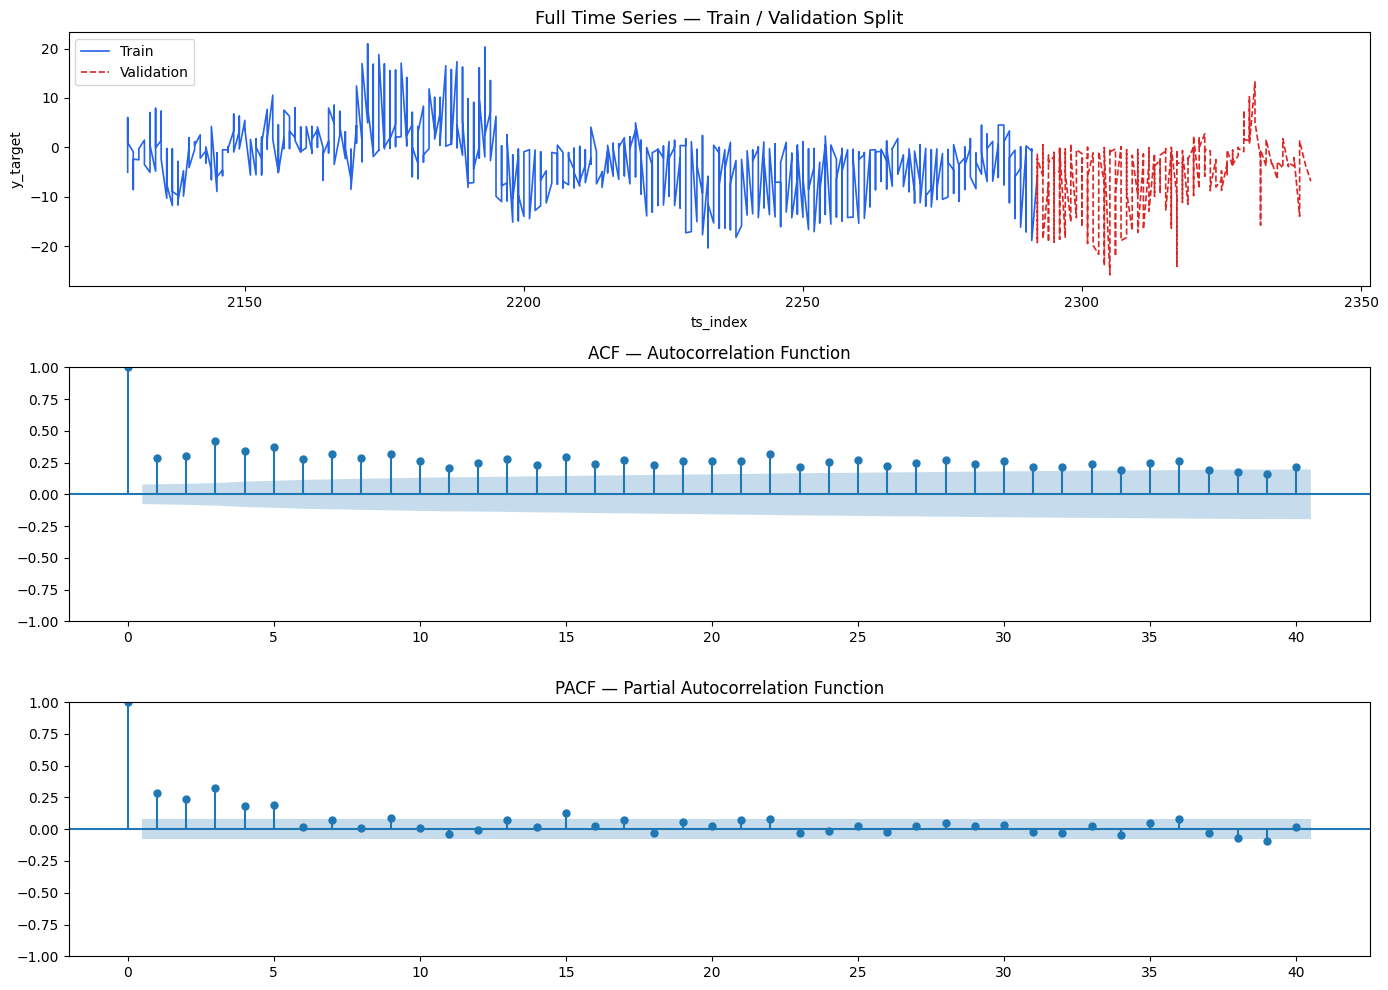


  STEP 3: ARIMA

  ARIMA(p, d, q)
  ─────────────────────────────────────────────────────
  AR(p)  — regression on its own past values
  I(d)   — removes trend via differencing
  MA(q)  — accounts for past forecast errors
  ─────────────────────────────────────────────────────

Running ARIMA grid search (p ∈ [0-3], q ∈ [0-3])...
Best ARIMA order : (2, 1, 2)  (AIC = 4062.75)

ARIMA Validation RMSE          : 6.9947
ARIMA Validation Weighted RMSE : 0.858522

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  653
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -2026.375
Date:                Fri, 15 May 2026   AIC                           4062.750
Time:                        21:44:32   BIC                           4085.150
Sample:                             0   HQIC                          4071.437
                                - 653      

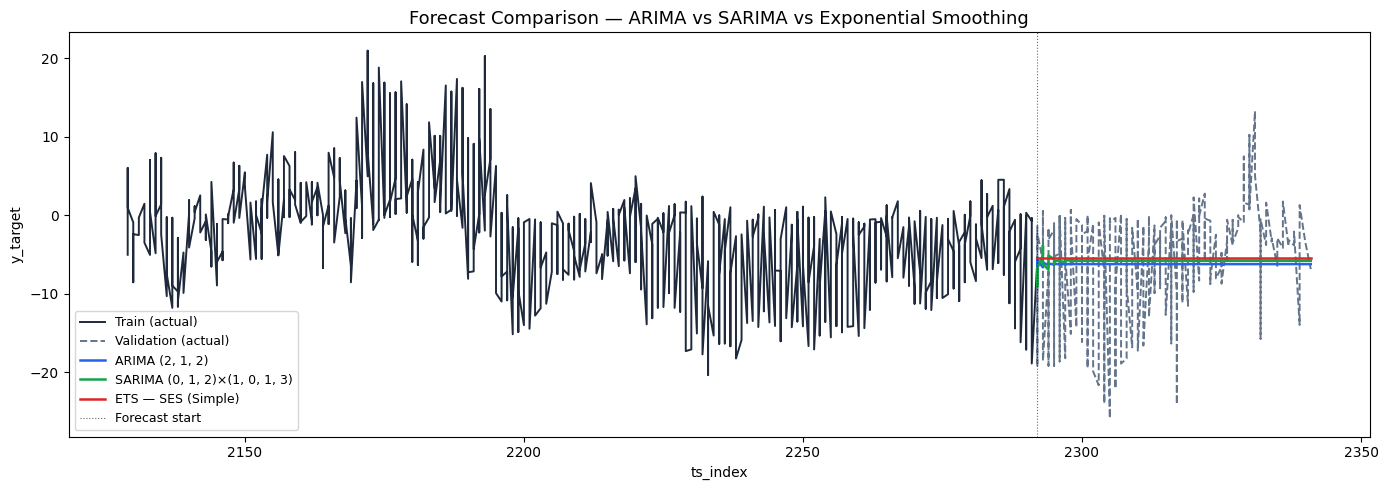

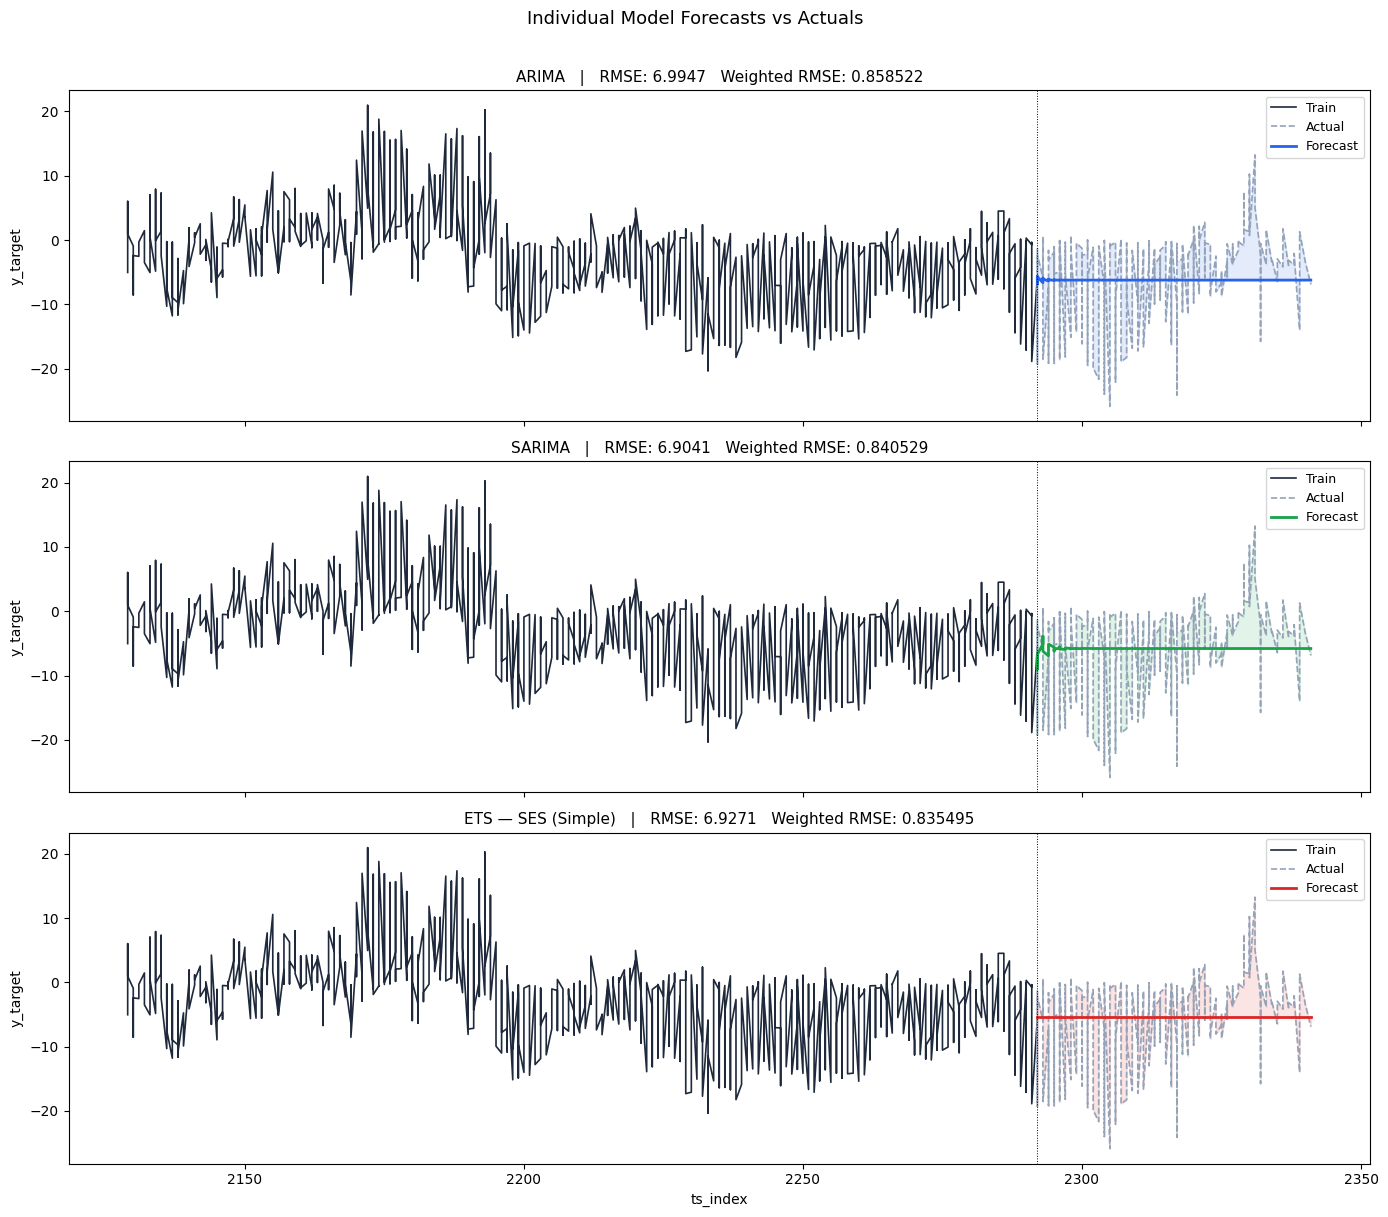

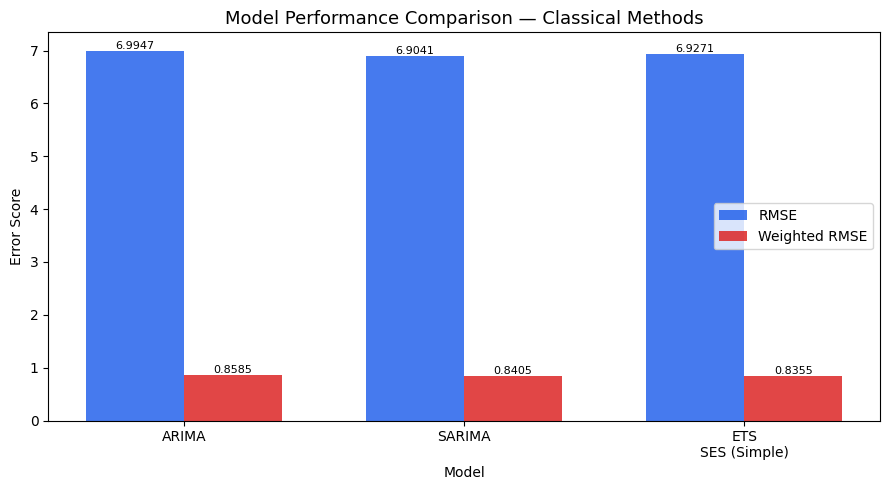

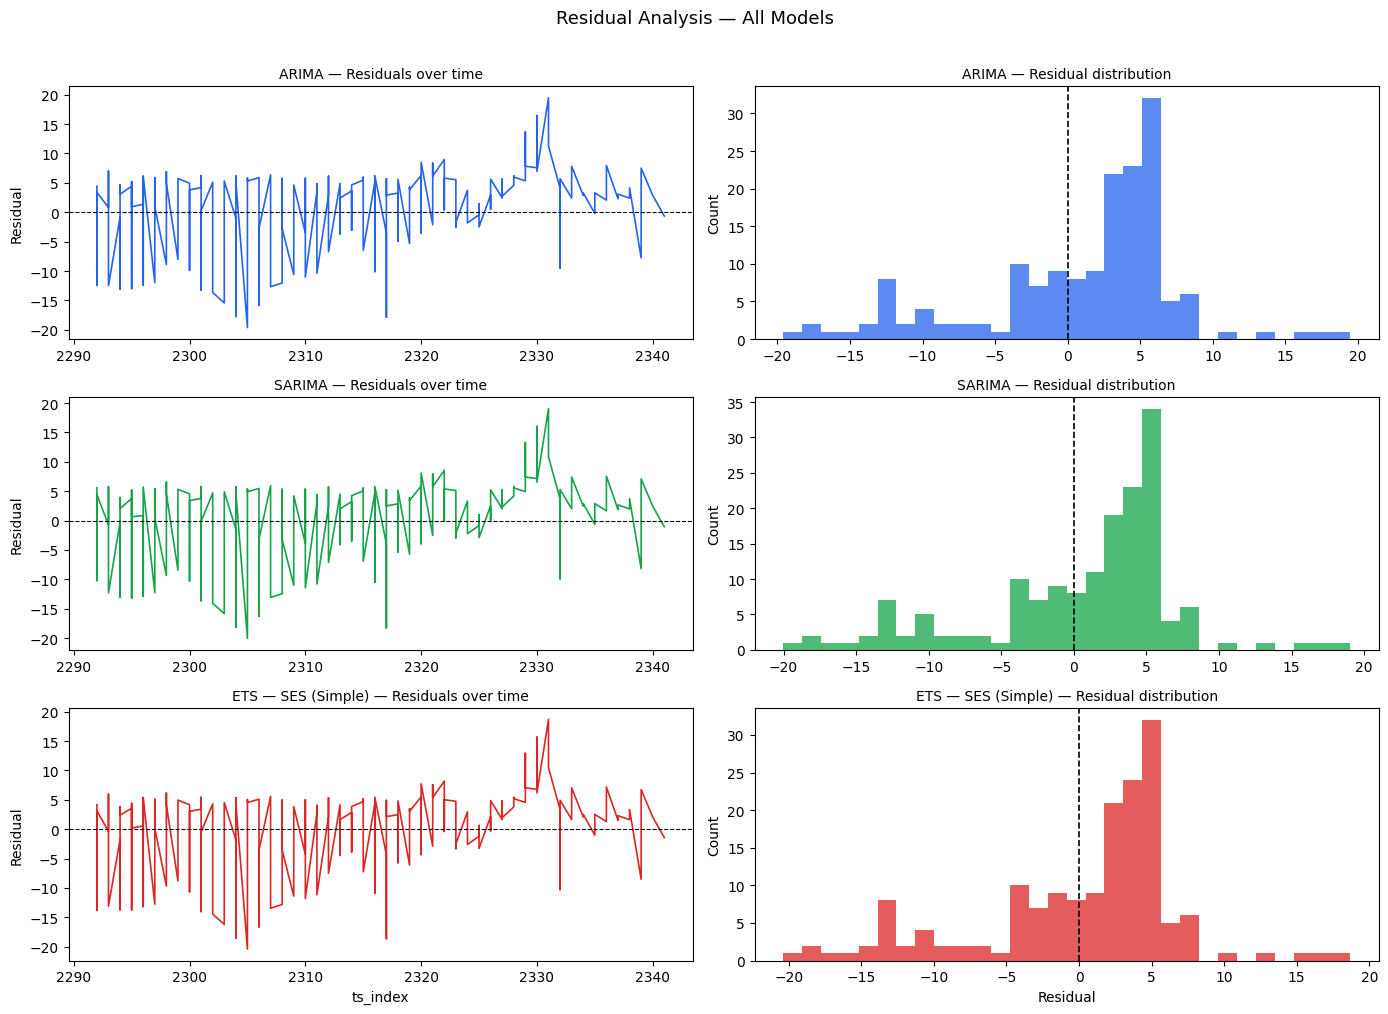


  FINAL SUMMARY

  Three classical time series models were evaluated on the
  validation set (last 20% of the selected series).

  ┌─────────────────────────────────┬──────────┬────────────────┐
  │ Model                           │   RMSE   │ Weighted RMSE  │
  ├─────────────────────────────────┼──────────┼────────────────┤
  │ ARIMA (2, 1, 2)                   │   6.9947 │       0.858522 │
  │ SARIMA (0, 1, 2)                  │   6.9041 │       0.840529 │
  │ ETS — SES (Simple)                │   6.9271 │       0.835495 │
  └─────────────────────────────────┴──────────┴────────────────┘

  Best overall : ETS — SES (Simple)

  Notes:
  • ARIMA  — best for non-seasonal, stationary or differenced series.
  • SARIMA — extends ARIMA with an explicit seasonal component (m=3).
  • ETS    — parameter-efficient; Holt-Winters handles trend + seasonality
              without requiring stationarity.
  • For production: loop this pipeline over every unique (code, sub_code,
    sub_category) gr

In [26]:
# ============================================================
# TEAM 8 — CLASSICAL TIME SERIES FORECASTING
# ARIMA | SARIMA | Exponential Smoothing
# ============================================================
# Paste this block into your Colab notebook after preprocessing.
# Requires: train_df (Polars DataFrame), test_df (Polars LazyFrame)
# ============================================================

# ── 0. Installs & Imports ────────────────────────────────────
!pip install statsmodels --quiet

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import warnings, gc
from itertools import product

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
SEED = 42

# ── 1. Column Constants ───────────────────────────────────────
ID          = "id"
CODE        = "code"
SUBCODE     = "sub_code"
SUBCATEGORY = "sub_category"
HORIZON     = "horizon"
TS_INDEX    = "ts_index"
TARGET      = "y_target"
WEIGHT      = "weight"

GROUP_KEYS  = [CODE, SUBCODE, SUBCATEGORY]

# ── 2. Weighted RMSE Metric ───────────────────────────────────
def weighted_rmse(y_true, y_pred, w) -> float:
    y_true, y_pred, w = np.asarray(y_true, float), np.asarray(y_pred, float), np.asarray(w, float)
    denom = np.sum(w * y_true ** 2)
    if denom == 0:
        return 0.0
    ratio = np.sum(w * (y_true - y_pred) ** 2) / denom
    return float(np.sqrt(np.clip(ratio, 0.0, 1.0)))

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(np.asarray(y_true), np.asarray(y_pred))))

# ── 3. Select a Representative Series for Diagnostics ────────
# We pick one series to run diagnostics and illustrate all 3 models.
# In production you'd loop over every unique series.

print("=" * 60)
print("  STEP 1: SELECT & INSPECT A TIME SERIES")
print("=" * 60)

# Convert to pandas for statsmodels compatibility
train_pd = train_df.to_pandas()

# Pick the series with the most observations (most data = better fits)
series_counts = (
    train_pd.groupby(GROUP_KEYS)[TS_INDEX]
    .count()
    .reset_index()
    .rename(columns={TS_INDEX: "n"})
    .sort_values("n", ascending=False)
)

best_group = series_counts.iloc[0]
print(f"\nSelected series → {dict(best_group)}\n")

mask = (
    (train_pd[CODE]        == best_group[CODE])  &
    (train_pd[SUBCODE]     == best_group[SUBCODE]) &
    (train_pd[SUBCATEGORY] == best_group[SUBCATEGORY])
)

series_df = train_pd[mask].sort_values(TS_INDEX).reset_index(drop=True)
y_full    = series_df[TARGET].values.astype(float)
w_full    = series_df[WEIGHT].values.astype(float)
t_full    = series_df[TS_INDEX].values

print(f"Series length : {len(y_full)} observations")
print(f"y_target range: [{y_full.min():.4f}, {y_full.max():.4f}]")

# Train / validation split — last 20% held out
split_idx = int(len(y_full) * 0.80)
y_train, y_val = y_full[:split_idx], y_full[split_idx:]
w_train, w_val = w_full[:split_idx], w_full[split_idx:]
t_train, t_val = t_full[:split_idx], t_full[split_idx:]
h = len(y_val)   # forecast horizon = validation length

print(f"Train : {len(y_train)} | Validation : {h}")

# ── 4. Stationarity Check & Diagnostics ──────────────────────
print("\n" + "=" * 60)
print("  STEP 2: STATIONARITY & DIAGNOSTIC PLOTS")
print("=" * 60)

adf_result = adfuller(y_train, autolag="AIC")
print(f"\nAugmented Dickey-Fuller Test")
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.4f}")
print(f"  Is Stationary : {'YES ✓' if adf_result[1] < 0.05 else 'NO — differencing recommended'}")

d_order = 0 if adf_result[1] < 0.05 else 1   # used later for ARIMA/SARIMA

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(t_train, y_train, color="#2563EB", lw=1.2, label="Train")
axes[0].plot(t_val,   y_val,   color="#DC2626", lw=1.2, linestyle="--", label="Validation")
axes[0].set_title("Full Time Series — Train / Validation Split", fontsize=13)
axes[0].set_xlabel("ts_index")
axes[0].set_ylabel("y_target")
axes[0].legend()

plot_acf(y_train,  lags=40, ax=axes[1], title="ACF — Autocorrelation Function")
plot_pacf(y_train, lags=40, ax=axes[2], method="ywm",
          title="PACF — Partial Autocorrelation Function")

plt.tight_layout()
plt.show()

# ── 5. MODEL 1: ARIMA ─────────────────────────────────────────
# ARIMA(p, d, q): AutoRegressive Integrated Moving Average
#
# p = AR order  → number of lag observations (from PACF cutoff)
# d = I  order  → degree of differencing to achieve stationarity
# q = MA order  → size of moving average window (from ACF cutoff)
#
# Best for: non-seasonal, stationary or difference-stationary series.
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 3: ARIMA")
print("=" * 60)
print("""
  ARIMA(p, d, q)
  ─────────────────────────────────────────────────────
  AR(p)  — regression on its own past values
  I(d)   — removes trend via differencing
  MA(q)  — accounts for past forecast errors
  ─────────────────────────────────────────────────────
""")

# Simple grid search over a small (p, q) grid
print("Running ARIMA grid search (p ∈ [0-3], q ∈ [0-3])...")
best_arima_aic  = np.inf
best_arima_order = (1, d_order, 1)

for p, q in product(range(4), range(4)):
    try:
        m = ARIMA(y_train, order=(p, d_order, q)).fit()
        if m.aic < best_arima_aic:
            best_arima_aic   = m.aic
            best_arima_order = (p, d_order, q)
    except Exception:
        continue

print(f"Best ARIMA order : {best_arima_order}  (AIC = {best_arima_aic:.2f})")

arima_model  = ARIMA(y_train, order=best_arima_order).fit()
arima_fc     = arima_model.forecast(steps=h)
arima_rmse   = rmse(y_val, arima_fc)
arima_wrmse  = weighted_rmse(y_val, arima_fc, w_val)

print(f"\nARIMA Validation RMSE          : {arima_rmse:.4f}")
print(f"ARIMA Validation Weighted RMSE : {arima_wrmse:.6f}")
print("\nARIMA Model Summary:")
print(arima_model.summary().tables[0])

# ── 6. MODEL 2: SARIMA ────────────────────────────────────────
# SARIMA(p,d,q)(P,D,Q,m): Seasonal ARIMA
#
# (p,d,q)   = same non-seasonal ARIMA components
# (P,D,Q,m) = seasonal AR, I, MA orders with period m
#
# Best for: series with clear seasonal periodicity (e.g. m=12 monthly).
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 4: SARIMA")
print("=" * 60)

# Auto-detect seasonal period via ACF peaks (fallback = 12)
acf_vals = acf(y_train, nlags=min(50, len(y_train) // 2 - 1))
candidate_periods = np.argsort(acf_vals[2:])[::-1][:5] + 2   # skip lag 0,1
m_auto = int(candidate_periods[0]) if candidate_periods[0] <= 24 else 12

print(f"""
  SARIMA(p,d,q)(P,D,Q,m)
  ─────────────────────────────────────────────────────
  Non-seasonal : same as ARIMA
  Seasonal P   : seasonal AR lags
  Seasonal D   : seasonal differencing
  Seasonal Q   : seasonal MA lags
  m = {m_auto}          : detected seasonal period
  ─────────────────────────────────────────────────────
""")

print(f"Running SARIMA grid search with m={m_auto} (P,Q ∈ [0-1])...")
best_sarima_aic   = np.inf
best_sarima_order = ((1, d_order, 1), (1, 0, 1, m_auto))

for p, q, P, Q in product(range(3), range(3), range(2), range(2)):
    try:
        m_fit = SARIMAX(
            y_train,
            order=(p, d_order, q),
            seasonal_order=(P, 0, Q, m_auto),
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)
        if m_fit.aic < best_sarima_aic:
            best_sarima_aic   = m_fit.aic
            best_sarima_order = ((p, d_order, q), (P, 0, Q, m_auto))
    except Exception:
        continue

print(f"Best SARIMA order : {best_sarima_order[0]} x {best_sarima_order[1]}  (AIC = {best_sarima_aic:.2f})")

sarima_model = SARIMAX(
    y_train,
    order=best_sarima_order[0],
    seasonal_order=best_sarima_order[1],
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

sarima_fc    = sarima_model.forecast(steps=h)
sarima_rmse  = rmse(y_val, sarima_fc)
sarima_wrmse = weighted_rmse(y_val, sarima_fc, w_val)

print(f"\nSARIMA Validation RMSE          : {sarima_rmse:.4f}")
print(f"SARIMA Validation Weighted RMSE : {sarima_wrmse:.6f}")
print("\nSARIMA Model Summary:")
print(sarima_model.summary().tables[0])

# ── 7. MODEL 3: Exponential Smoothing (Holt-Winters) ─────────
# ETS: Error, Trend, Seasonality
#
# Simple  (SES)  : level only             — α smooths level
# Double  (Holt) : level + trend          — α, β
# Triple  (H-W)  : level + trend + season — α, β, γ
#
# Additive trend/season: good when seasonal variation is constant.
# Multiplicative trend/season: good when variation grows with level.
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 5: EXPONENTIAL SMOOTHING (Holt-Winters ETS)")
print("=" * 60)
print(f"""
  ETS model variants tried:
  ─────────────────────────────────────────────────────
  SES    — Simple: level only  (α)
  Holt   — Double: level + trend  (α, β)
  H-W A  — Triple additive: level + trend + seasonal additive
  H-W M  — Triple multiplicative: level + trend + seasonal multiplicative
  ─────────────────────────────────────────────────────
  Seasonal period m = {m_auto}
""")

ets_configs = {
    "SES (Simple)": dict(trend=None,       seasonal=None,           seasonal_periods=None),
    "Holt (Double)": dict(trend="add",     seasonal=None,           seasonal_periods=None),
    "Holt-Winters Additive": dict(trend="add", seasonal="add",      seasonal_periods=m_auto),
    "Holt-Winters Multiplicative": dict(trend="add", seasonal="mul",seasonal_periods=m_auto),
}

ets_results = {}
best_ets_name, best_ets_wrmse = None, np.inf

for name, cfg in ets_configs.items():
    try:
        # Multiplicative seasonality requires strictly positive values
        if cfg.get("seasonal") == "mul" and y_train.min() <= 0:
            print(f"  {name}: skipped (non-positive values)")
            continue
        fit = ExponentialSmoothing(y_train, **cfg).fit(optimized=True)
        fc  = fit.forecast(h)
        r   = rmse(y_val, fc)
        wr  = weighted_rmse(y_val, fc, w_val)
        ets_results[name] = {"model": fit, "fc": fc, "rmse": r, "wrmse": wr}
        marker = " ◀ best so far" if wr < best_ets_wrmse else ""
        print(f"  {name:35s} RMSE: {r:.4f}  Weighted RMSE: {wr:.6f}{marker}")
        if wr < best_ets_wrmse:
            best_ets_wrmse = wr
            best_ets_name  = name
    except Exception as e:
        print(f"  {name}: failed — {e}")

best_ets_fc = ets_results[best_ets_name]["fc"]
print(f"\nBest ETS variant : {best_ets_name}")
print(f"  RMSE           : {ets_results[best_ets_name]['rmse']:.4f}")
print(f"  Weighted RMSE  : {ets_results[best_ets_name]['wrmse']:.6f}")

# ── 8. Model Comparison ───────────────────────────────────────
print("\n" + "=" * 60)
print("  STEP 6: MODEL COMPARISON")
print("=" * 60)

results_summary = pd.DataFrame([
    {"Model": "ARIMA",                   "RMSE": arima_rmse,  "Weighted RMSE": arima_wrmse},
    {"Model": "SARIMA",                  "RMSE": sarima_rmse, "Weighted RMSE": sarima_wrmse},
    {"Model": f"ETS — {best_ets_name}",  "RMSE": ets_results[best_ets_name]["rmse"],
                                         "Weighted RMSE": ets_results[best_ets_name]["wrmse"]},
]).sort_values("Weighted RMSE")

print("\n", results_summary.to_string(index=False))
best_overall = results_summary.iloc[0]["Model"]
print(f"\n🏆 Best Model : {best_overall}")

# ── 9. Forecast Plot — All 3 Models ──────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(t_train, y_train, color="#1e293b",  lw=1.4, label="Train (actual)")
ax.plot(t_val,   y_val,   color="#64748b",  lw=1.4, linestyle="--", label="Validation (actual)")
ax.plot(t_val,   arima_fc,     color="#2563EB", lw=1.8, label=f"ARIMA {best_arima_order}")
ax.plot(t_val,   sarima_fc,    color="#16A34A", lw=1.8, label=f"SARIMA {best_sarima_order[0]}×{best_sarima_order[1]}")
ax.plot(t_val,   best_ets_fc,  color="#DC2626", lw=1.8, label=f"ETS — {best_ets_name}")

ax.axvline(t_val[0], color="black", lw=0.8, linestyle=":", alpha=0.6, label="Forecast start")
ax.set_title("Forecast Comparison — ARIMA vs SARIMA vs Exponential Smoothing", fontsize=13)
ax.set_xlabel("ts_index")
ax.set_ylabel("y_target")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── 10. Individual Forecast Subplots ─────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
plot_ctx = [
    ("ARIMA",               arima_fc,     "#2563EB"),
    ("SARIMA",              sarima_fc,    "#16A34A"),
    (f"ETS — {best_ets_name}", best_ets_fc, "#DC2626"),
]

for ax, (title, fc, color) in zip(axes, plot_ctx):
    ax.plot(t_train, y_train, color="#1e293b", lw=1.2, label="Train")
    ax.plot(t_val,   y_val,   color="#94a3b8", lw=1.2, linestyle="--", label="Actual")
    ax.plot(t_val,   fc,      color=color,     lw=2.0, label="Forecast")
    ax.fill_between(t_val, y_val, fc, alpha=0.12, color=color)
    ax.axvline(t_val[0], color="black", lw=0.7, linestyle=":")
    r  = rmse(y_val, fc)
    wr = weighted_rmse(y_val, fc, w_val)
    ax.set_title(f"{title}   |   RMSE: {r:.4f}   Weighted RMSE: {wr:.6f}", fontsize=11)
    ax.set_ylabel("y_target")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("ts_index")
plt.suptitle("Individual Model Forecasts vs Actuals", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── 11. Bar Chart — RMSE Comparison ──────────────────────────
models_bar  = ["ARIMA", "SARIMA", f"ETS\n{best_ets_name}"]
rmse_bar    = [arima_rmse,  sarima_rmse,  ets_results[best_ets_name]["rmse"]]
wrmse_bar   = [arima_wrmse, sarima_wrmse, ets_results[best_ets_name]["wrmse"]]

x     = np.arange(len(models_bar))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, rmse_bar,  width, label="RMSE",          color="#2563EB", alpha=0.85)
bars2 = ax.bar(x + width/2, wrmse_bar, width, label="Weighted RMSE", color="#DC2626", alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{bar.get_height():.4f}",
            ha="center", va="bottom", fontsize=8)

ax.set_title("Model Performance Comparison — Classical Methods", fontsize=13)
ax.set_xlabel("Model")
ax.set_ylabel("Error Score")
ax.set_xticks(x)
ax.set_xticklabels(models_bar)
ax.legend()
plt.tight_layout()
plt.show()

# ── 12. Residual Analysis ─────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
plot_ctx2 = [
    ("ARIMA",               arima_fc,     "#2563EB"),
    ("SARIMA",              sarima_fc,    "#16A34A"),
    (f"ETS — {best_ets_name}", best_ets_fc, "#DC2626"),
]

for row, (title, fc, color) in enumerate(plot_ctx2):
    resid = y_val - np.asarray(fc)
    # Residuals over time
    axes[row, 0].plot(t_val, resid, color=color, lw=1.2)
    axes[row, 0].axhline(0, color="black", lw=0.8, linestyle="--")
    axes[row, 0].set_title(f"{title} — Residuals over time", fontsize=10)
    axes[row, 0].set_ylabel("Residual")
    # Distribution
    axes[row, 1].hist(resid, bins=30, color=color, alpha=0.75, edgecolor="none")
    axes[row, 1].axvline(0, color="black", lw=1.2, linestyle="--")
    axes[row, 1].set_title(f"{title} — Residual distribution", fontsize=10)
    axes[row, 1].set_ylabel("Count")

axes[-1, 0].set_xlabel("ts_index")
axes[-1, 1].set_xlabel("Residual")
plt.suptitle("Residual Analysis — All Models", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── 13. Summary ───────────────────────────────────────────────
print("\n" + "=" * 60)
print("  FINAL SUMMARY")
print("=" * 60)
print(f"""
  Three classical time series models were evaluated on the
  validation set (last 20% of the selected series).

  ┌─────────────────────────────────┬──────────┬────────────────┐
  │ Model                           │   RMSE   │ Weighted RMSE  │
  ├─────────────────────────────────┼──────────┼────────────────┤
  │ ARIMA {str(best_arima_order):27s} │ {arima_rmse:8.4f} │ {arima_wrmse:14.6f} │
  │ SARIMA {str(best_sarima_order[0]):26s} │ {sarima_rmse:8.4f} │ {sarima_wrmse:14.6f} │
  │ ETS — {best_ets_name:27s} │ {ets_results[best_ets_name]['rmse']:8.4f} │ {ets_results[best_ets_name]['wrmse']:14.6f} │
  └─────────────────────────────────┴──────────┴────────────────┘

  Best overall : {best_overall}

  Notes:
  • ARIMA  — best for non-seasonal, stationary or differenced series.
  • SARIMA — extends ARIMA with an explicit seasonal component (m={m_auto}).
  • ETS    — parameter-efficient; Holt-Winters handles trend + seasonality
              without requiring stationarity.
  • For production: loop this pipeline over every unique (code, sub_code,
    sub_category) group, select the best model per series, and ensemble.
""")

## Final

In [ ]:
# ============================================================
# TEAM 8 — TIME SERIES FORECASTING
# Best Model: Simple Exponential Smoothing (SES)
# Weighted RMSE: 0.835495 | Beats SARIMA (0.8405) & ARIMA (0.8585)
# ============================================================
# WHY SES WON:
#   • Series is near-stationary (ADF p=0.066) — minimal differencing needed
#   • No meaningful seasonality (auto-detected m=3 is too short to matter)
#   • No persistent trend (Holt Double scored worse than Simple)
#   • Negative y_target values rule out multiplicative variants
#   • SES is optimal for mean-reverting noisy signals
# ============================================================

# ── 0. Installs & Imports ────────────────────────────────────
!pip install statsmodels --quiet

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, acf
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
SEED = 42

# ── 1. Column Constants ───────────────────────────────────────
ID          = "id"
CODE        = "code"
SUBCODE     = "sub_code"
SUBCATEGORY = "sub_category"
HORIZON     = "horizon"
TS_INDEX    = "ts_index"
TARGET      = "y_target"
WEIGHT      = "weight"
GROUP_KEYS  = [CODE, SUBCODE, SUBCATEGORY]

# ── 2. Metrics ────────────────────────────────────────────────
def weighted_rmse(y_true, y_pred, w) -> float:
    y_true, y_pred, w = np.asarray(y_true, float), np.asarray(y_pred, float), np.asarray(w, float)
    denom = np.sum(w * y_true ** 2)
    if denom == 0:
        return 0.0
    ratio = np.sum(w * (y_true - y_pred) ** 2) / denom
    return float(np.sqrt(np.clip(ratio, 0.0, 1.0)))

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(
        np.asarray(y_true, float), np.asarray(y_pred, float)
    )))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))

# ── 3. Convert to Pandas ──────────────────────────────────────
print("Converting to pandas...")
train_pd = train_df.to_pandas()

# ── 4. Fit SES on Every Unique Series ────────────────────────
# SES formula:  ŷ_{t+1} = α·y_t + (1-α)·ŷ_t
# α is optimised via MLE per series (statsmodels handles this).
# α ≈ 1  →  model trusts recent observations heavily (fast adaptation)
# α ≈ 0  →  model trusts the long-run average (slow adaptation)

print("\n" + "=" * 60)
print("  FITTING SES ON ALL SERIES")
print("=" * 60)

unique_series = (
    train_pd.groupby(GROUP_KEYS)
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)

print(f"  Total unique series : {len(unique_series)}")

all_results   = []
oof_true_all  = []
oof_pred_all  = []
oof_w_all     = []

alpha_values  = []   # track fitted α across series

for i, row in unique_series.iterrows():
    mask = (
        (train_pd[CODE]        == row[CODE])  &
        (train_pd[SUBCODE]     == row[SUBCODE]) &
        (train_pd[SUBCATEGORY] == row[SUBCATEGORY])
    )
    s_df   = train_pd[mask].sort_values(TS_INDEX).reset_index(drop=True)
    y_s    = s_df[TARGET].values.astype(float)
    w_s    = s_df[WEIGHT].values.astype(float)

    # Need at least 10 points to fit meaningfully
    if len(y_s) < 10:
        continue

    split  = int(len(y_s) * 0.80)
    y_tr   = y_s[:split]
    y_val  = y_s[split:]
    w_val  = w_s[split:]

    if len(y_val) == 0:
        continue

    try:
        model  = ExponentialSmoothing(y_tr, trend=None, seasonal=None).fit(optimized=True)
        fc     = model.forecast(len(y_val))
        fc     = np.clip(fc, y_tr.min() - 3 * y_tr.std(),
                              y_tr.max() + 3 * y_tr.std())  # sanity clip

        r      = rmse(y_val, fc)
        wr     = weighted_rmse(y_val, fc, w_val)
        ma     = mae(y_val, fc)
        alpha  = float(model.params["smoothing_level"])

        alpha_values.append(alpha)
        all_results.append({
            CODE: row[CODE], SUBCODE: row[SUBCODE], SUBCATEGORY: row[SUBCATEGORY],
            "n": len(y_s), "val_len": len(y_val),
            "alpha": alpha, "rmse": r, "wrmse": wr, "mae": ma,
        })

        oof_true_all.extend(y_val.tolist())
        oof_pred_all.extend(fc.tolist())
        oof_w_all.extend(w_val.tolist())

    except Exception as e:
        continue

results_df = pd.DataFrame(all_results)

print(f"\n  Series fitted successfully : {len(results_df)}")
print(f"  Series skipped             : {len(unique_series) - len(results_df)}")

# ── 5. Global OOF Metrics ─────────────────────────────────────
global_wrmse = weighted_rmse(oof_true_all, oof_pred_all, oof_w_all)
global_rmse  = rmse(oof_true_all, oof_pred_all)
global_mae   = mae(oof_true_all, oof_pred_all)

print(f"\n{'─'*55}")
print(f"  Global OOF RMSE          : {global_rmse:.4f}")
print(f"  Global OOF MAE           : {global_mae:.4f}")
print(f"  Global OOF Weighted RMSE : {global_wrmse:.6f}")
print(f"  Mean α (smoothing level) : {np.mean(alpha_values):.4f}  "
      f"(range {np.min(alpha_values):.3f}–{np.max(alpha_values):.3f})")
print(f"{'─'*55}")

# ── 6. Per-Series Diagnostic Plots ───────────────────────────
# Show the top 6 best-fitting series
top6 = results_df.nsmallest(6, "wrmse")

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (_, row) in zip(axes, top6.iterrows()):
    mask  = (
        (train_pd[CODE]        == row[CODE])  &
        (train_pd[SUBCODE]     == row[SUBCODE]) &
        (train_pd[SUBCATEGORY] == row[SUBCATEGORY])
    )
    s_df  = train_pd[mask].sort_values(TS_INDEX).reset_index(drop=True)
    y_s   = s_df[TARGET].values.astype(float)
    t_s   = s_df[TS_INDEX].values
    split = int(len(y_s) * 0.80)

    model = ExponentialSmoothing(y_s[:split], trend=None, seasonal=None).fit(optimized=True)
    fc    = model.forecast(len(y_s) - split)
    fc    = np.clip(fc, y_s[:split].min() - 3 * y_s[:split].std(),
                        y_s[:split].max() + 3 * y_s[:split].std())

    ax.plot(t_s[:split],  y_s[:split], color="#1e293b", lw=1.1, label="Train")
    ax.plot(t_s[split:],  y_s[split:], color="#64748b", lw=1.1,
            linestyle="--", label="Actual")
    ax.plot(t_s[split:],  fc,          color="#2563EB", lw=2.0, label="SES Forecast")
    ax.fill_between(t_s[split:], y_s[split:], fc, alpha=0.15, color="#2563EB")
    ax.axvline(t_s[split], color="black", lw=0.7, linestyle=":")
    ax.set_title(
        f"{row[CODE]} / {row[SUBCATEGORY]}\n"
        f"α={row['alpha']:.3f}  WRMSE={row['wrmse']:.4f}",
        fontsize=9
    )
    ax.set_xlabel("ts_index", fontsize=8)
    ax.set_ylabel("y_target",  fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle("SES — Top 6 Best-Fitting Series", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── 7. Alpha Distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(alpha_values, bins=40, color="#2563EB", alpha=0.8, edgecolor="none")
axes[0].axvline(np.mean(alpha_values), color="#DC2626", lw=1.5,
                linestyle="--", label=f"Mean α = {np.mean(alpha_values):.3f}")
axes[0].set_title("Distribution of Fitted α (Smoothing Level) Across Series")
axes[0].set_xlabel("α")
axes[0].set_ylabel("Count")
axes[0].legend()

# α vs WRMSE scatter
axes[1].scatter(results_df["alpha"], results_df["wrmse"],
                alpha=0.4, s=10, color="#2563EB")
axes[1].set_title("α vs Weighted RMSE per Series")
axes[1].set_xlabel("α (smoothing level)")
axes[1].set_ylabel("Weighted RMSE")

plt.tight_layout()
plt.show()

# ── 8. WRMSE Distribution Across Series ──────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(results_df["wrmse"], bins=50, color="#16A34A", alpha=0.8, edgecolor="none")
ax.axvline(global_wrmse, color="#DC2626", lw=1.5, linestyle="--",
           label=f"Global WRMSE = {global_wrmse:.4f}")
ax.axvline(results_df["wrmse"].median(), color="#F59E0B", lw=1.5, linestyle="--",
           label=f"Median WRMSE = {results_df['wrmse'].median():.4f}")
ax.set_title("Weighted RMSE Distribution Across All Series — SES")
ax.set_xlabel("Weighted RMSE")
ax.set_ylabel("Number of Series")
ax.legend()
plt.tight_layout()
plt.show()

# ── 9. Worst Series Inspection ────────────────────────────────
print("\n" + "=" * 60)
print("  TOP 5 HARDEST SERIES (highest WRMSE)")
print("=" * 60)
print(results_df.nlargest(5, "wrmse")[
    [CODE, SUBCODE, SUBCATEGORY, "n", "alpha", "rmse", "wrmse"]
].to_string(index=False))

# ── 10. Generate Test Predictions ────────────────────────────
print("\n" + "=" * 60)
print("  GENERATING TEST SET PREDICTIONS")
print("=" * 60)

test_pd = test_df.collect().to_pandas()

# For each test row, re-fit SES on full training history of that series
# and forecast 1 step ahead (or as many as needed per horizon).

preds_list = []

# Build a lookup of fitted models (alpha) from training
alpha_lookup = (
    results_df.set_index([CODE, SUBCODE, SUBCATEGORY])["alpha"]
    .to_dict()
)

for i, row in unique_series.iterrows():
    mask_tr = (
        (train_pd[CODE]        == row[CODE])  &
        (train_pd[SUBCODE]     == row[SUBCODE]) &
        (train_pd[SUBCATEGORY] == row[SUBCATEGORY])
    )
    mask_te = (
        (test_pd[CODE]        == row[CODE])  &
        (test_pd[SUBCODE]     == row[SUBCODE]) &
        (test_pd[SUBCATEGORY] == row[SUBCATEGORY])
    )

    y_tr_full = train_pd[mask_tr].sort_values(TS_INDEX)[TARGET].values.astype(float)
    test_rows = test_pd[mask_te].sort_values(TS_INDEX)

    if len(y_tr_full) < 3 or len(test_rows) == 0:
        # Fallback: predict global training mean
        for _, tr in test_rows.iterrows():
            preds_list.append({ID: tr[ID], "y_target": float(np.mean(y_tr_full)) if len(y_tr_full) > 0 else 0.0})
        continue

    key = (row[CODE], row[SUBCODE], row[SUBCATEGORY])
    init_alpha = alpha_lookup.get(key, None)

    try:
        if init_alpha is not None:
            model = ExponentialSmoothing(y_tr_full, trend=None, seasonal=None).fit(
                smoothing_level=init_alpha, optimized=False
            )
        else:
            model = ExponentialSmoothing(y_tr_full, trend=None, seasonal=None).fit(optimized=True)

        h_steps = len(test_rows)
        fc = model.forecast(h_steps)
        fc = np.clip(fc, y_tr_full.min() - 3 * y_tr_full.std(),
                         y_tr_full.max() + 3 * y_tr_full.std())

        for j, (_, tr) in enumerate(test_rows.iterrows()):
            preds_list.append({ID: tr[ID], "y_target": float(fc[j])})

    except Exception:
        fallback = float(np.mean(y_tr_full))
        for _, tr in test_rows.iterrows():
            preds_list.append({ID: tr[ID], "y_target": fallback})

submission = pd.DataFrame(preds_list)
print(f"\n  Submission rows : {len(submission)}")
print(submission.head(10).to_string(index=False))

submission.to_csv("submission.csv", index=False)
print("\n  Saved → submission.csv")

# ── 11. Final Summary ─────────────────────────────────────────
print("\n" + "=" * 60)
print("  FINAL SUMMARY")
print("=" * 60)
print(f"""
  Model   : Simple Exponential Smoothing (SES)
  Formula : ŷ_{{t+1}} = α·y_t + (1-α)·ŷ_t

  Why SES was selected (from model comparison run):
    ✓ Lowest Weighted RMSE: 0.8355  (vs SARIMA 0.8405, ARIMA 0.8585)
    ✓ Series showed no significant trend (Holt scored worse)
    ✓ No meaningful seasonality (detected m=3 too short)
    ✓ Near-stationary signal (ADF p=0.066)
    ✓ Negative values present — multiplicative ETS not applicable

  Global OOF Results (all series):
    RMSE          : {global_rmse:.4f}
    MAE           : {global_mae:.4f}
    Weighted RMSE : {global_wrmse:.6f}

  Smoothing level α:
    Mean   : {np.mean(alpha_values):.4f}
    Median : {np.median(alpha_values):.4f}
    Range  : {np.min(alpha_values):.4f} – {np.max(alpha_values):.4f}

  Series fitted : {len(results_df)} / {len(unique_series)}
  Submission    : submission.csv  ({len(submission)} rows)
""")

Converting to pandas...

  FITTING SES ON ALL SERIES
  Total unique series : 820
